# Cross-generation semantic-count comparison (aigen vs nogen vs plain)

Compares **feedback / generation types against each other** on raw semantic-tag counts
(`objects`, `stuff`, `scene_category`, `spatial_relations`, `attr_color`, `adjectives`).
This is the semantic-count complement to `cross_gen_similarity_comparison.ipynb`, and the
cross-generation counterpart to `aigen_semantic_counts.ipynb` (which compares *tasks* within
one generation). Here the comparison axis is **generation**.

Source: `<processed_dir>/nlp_analysis/trials_final_semantic_tags.csv` for each condition.
This is NOT a `config.FILENAMES` canonical table, so it is resolved by hand (like
`aigen_semantic_counts.ipynb`). Conditions without the file yet are skipped automatically:
add generations to `GENS` as their data lands — `plain` is forward-compatible and needs no
code change.

Each tag column is a stringified list; the count is its length.

**Raw counts only** — these are not yet validated against the image (see
`object_accuracy_detector.py` for that).

**`gpt-5.5_desc`.** `analysis/gpt_image_desc_api.py` asks GPT to write the same kind of prompt
*while looking at* each ground-truth image (one description per image), and tags it with the
**same tagger** used for the participants. That is an upper bound on how much a description of
these images can contain, with no memory load and no time limit, so it is drawn as a dashed
reference line rather than as another condition.

**Conventions** (identical to `cross_gen_similarity_comparison.ipynb`)
- One fixed, colorblind-safe color per **generation** (Dark2), reused in every figure.
- Three views: (1) counts over attempts, faceted by task; (2) improvement delta (attempt 3 - 1);
  (3) humans vs `gpt-5.5_desc` per category.

In [47]:
import sys
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find project root (the dir containing config.py) regardless of where the notebook sits.
project_root = Path.cwd()
while not (project_root / "config.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config
print("project root:", project_root)

project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [48]:
# --- Which generations to compare. Add "plain" once its semantic-tags CSVs exist. ---
GENS = ["aigen", "nogen", "plain"]
SEM_FILE = "trials_final_semantic_tags.csv"

# Semantic-tag categories: csv column -> nice axis label. Each cell is a stringified list.
CATEGORIES = {
    "objects": "Objects",
    "stuff": "Stuff",
    "scene_category": "Scene category",
    "spatial_relations": "Spatial relations",
    "attr_color": "Color attributes",
    "adjectives": "Adjectives",
}


def _count(cell):
    """Length of a stringified list cell; 0 for empty / NaN / unparseable."""
    if pd.isna(cell):
        return 0
    try:
        val = ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return 0
    return len(val) if isinstance(val, (list, tuple)) else 0


# The semantic-tags CSV lives in a nlp_analysis subfolder of each condition's processed_dir
# and is not a config.load canonical table, so we resolve + tag it by hand here.
slugs = [c for g in GENS for c in config.GROUPS_BY_GEN[g]]
frames = []
for c in slugs:
    p = config.paths_for(c).processed_dir / "nlp_analysis" / SEM_FILE
    if not p.exists():
        print(f"skip {c}: {SEM_FILE} not found ({p})")
        continue
    d = pd.read_csv(p)
    cm = config.mapping_data["CONDITIONS"][c]
    d["condition"], d["generation"], d["task"] = c, cm["generation"], cm["task"]
    for col in CATEGORIES:
        d[f"n_{col}"] = d[col].apply(_count)
    frames.append(d)
    print(f"loaded {c}: {len(d)} rows, {d['uid'].nunique()} participants")

df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
assert not df.empty, f"no {SEM_FILE} found for any of {slugs}"
df["attempt"] = df["attempt"].astype(int)

# Keep only generations that actually loaded (skips any without data yet).
GEN_ORDER = [g for g in ["aigen", "nogen", "plain"] if g in set(df["generation"])]

GRAPHS = config.ROOT / "analysis" / "outputs" / config.DATASET / "combined" / "graphs" / "nlp_graphs"
GRAPHS.mkdir(parents=True, exist_ok=True)
print("generations loaded:", GEN_ORDER, "-> saving figures to:", GRAPHS)
df.groupby(["generation", "task"]).size().unstack("task")

loaded aigen_perc: 279 rows, 20 participants
loaded aigen_imm: 327 rows, 23 participants
loaded aigen_del: 297 rows, 23 participants
loaded nogen_perc: 237 rows, 17 participants
loaded nogen_imm: 288 rows, 21 participants
loaded nogen_del: 222 rows, 18 participants
loaded plain_perc: 121 rows, 25 participants
loaded plain_imm: 114 rows, 25 participants
loaded plain_del: 96 rows, 20 participants
generations loaded: ['aigen', 'nogen', 'plain'] -> saving figures to: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs


task,delay,immediate,perception
generation,,,
aigen,297,327,279
nogen,222,288,237
plain,96,114,121


In [49]:
# --- Style + fixed color maps (per generation, reused in every figure) ---
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Presentation-sized type: everything scales off font_scale, then a few explicit bumps.
sns.set_theme(style="whitegrid", font_scale=1.6)
plt.rcParams.update({
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "legend.title_fontsize": 17,
    "figure.titlesize": 26,
})

TASK_ORDER  = ["perception", "immediate", "delay"]
TASK_LABELS = {"perception": "Perception", "immediate": "Immediate memory", "delay": "Delayed memory"}
ATTEMPTS    = [1, 2, 3]

# Dark2: green / orange / purple - one fixed color per generation (matches the similarity nb).
GEN_COLORS = {"aigen": "#1b9e77", "nogen": "#d95f02", "plain": "#7570b3"}
GEN_LABELS = {"aigen": "AI-gen (image)", "nogen": "No-gen (text)", "plain": "Plain (baseline)"}

# y ticks: always start at 0, and step in "nice" units chosen from the panel's range so a
# small category (scene_category, max ~3) and a large one (adjectives, max ~37) both get
# ~6-10 gridlines instead of 2 or 20. Set Y_TICK_STEP to a number to force one step everywhere.
Y_TICK_STEP = None
Y_TARGET_TICKS = 8


def _nice_step(vmax, target=Y_TARGET_TICKS):
    """Round vmax/target up to the nearest 1, 2, 5 x 10^k."""
    if not vmax or vmax <= 0:
        return 1
    raw = vmax / target
    mag = 10 ** np.floor(np.log10(raw))
    for m in (1, 2, 5, 10):
        if raw <= m * mag:
            return m * mag
    return 10 * mag


def _style_count_axis(ax, vmax=None):
    """y starts at 0; ticks every Y_TICK_STEP, or a nice auto step from the panel range."""
    ax.set_ylim(bottom=0)
    top = vmax if vmax is not None else ax.get_ylim()[1]
    ax.yaxis.set_major_locator(MultipleLocator(Y_TICK_STEP or _nice_step(top)))


def _dodge_offsets():
    """x offset of each generation's dodged slot, matching seaborn's categorical dodge
    (total slot width 0.8 split evenly between the hue levels)."""
    n = len(GEN_ORDER)
    width = 0.8 / n
    return {gen: (i - (n - 1) / 2) * width for i, gen in enumerate(GEN_ORDER)}


def _figure_legend(fig, marker="o", ncol=None, y=0.90):
    """One legend for the whole figure, centered above the panels.

    marker: "o" for the line views (colored line + dot), "bar" for the bar views (color patch).
    The gpt-5.5_desc dashed line is appended when it is loaded.
    """
    if marker == "bar":
        handles = [Patch(facecolor=GEN_COLORS[g], label=GEN_LABELS[g]) for g in GEN_ORDER]
    else:
        handles = [Line2D([], [], color=GEN_COLORS[g], lw=3, marker="o", markersize=9,
                          label=GEN_LABELS[g]) for g in GEN_ORDER]
    if GPT_DESC:
        handles.append(Line2D([], [], color=GPT_DESC_COLOR, lw=2.4, ls="--", label=GPT_DESC_LABEL))
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, y),
               ncol=ncol or len(handles), frameon=False, columnspacing=2.2,
               handlelength=2.4, handletextpad=0.9)


def _save(fig, out):
    """Save with padding, so the y label / legend are never clipped at the edge."""
    fig.savefig(out, dpi=300, bbox_inches="tight", pad_inches=0.35)
    print("saved:", out)

In [50]:
# --- gpt-5.5_desc: one GPT description per GT image, written while looking at the image -----
# Produced by `python analysis/gpt_image_desc_api.py` (verbosity medium), tagged with the same
# tagger as the trials, so the counts are directly comparable. Missing file -> reference omitted.
GPT_DESC_VERBOSITY = "medium"
GPT_DESC_DIR = config.COMBINED_PROCESSED_DIR / "gpt-5.5_desc"
GPT_DESC_PATH = GPT_DESC_DIR / f"gpt-5.5_desc_semantic_tags_verbosity-{GPT_DESC_VERBOSITY}.csv"
# The first run of the script wrote these under the older "gpt_ceiling" name; accept either so
# the line still appears before that folder is renamed.
LEGACY_GPT_DESC_PATH = (config.COMBINED_PROCESSED_DIR / "gpt_ceiling"
                        / f"gpt_ceiling_semantic_tags_verbosity-{GPT_DESC_VERBOSITY}.csv")
GPT_DESC_COLOR = "#444444"
GPT_DESC_LABEL = "gpt-5.5_desc"

_path = GPT_DESC_PATH if GPT_DESC_PATH.exists() else LEGACY_GPT_DESC_PATH
if _path.exists():
    gpt_desc_df = pd.read_csv(_path)
    for col in CATEGORIES:
        gpt_desc_df[f"n_{col}"] = gpt_desc_df[col].apply(_count)
    # Mean over the GT images: one gpt-5.5_desc value per category.
    GPT_DESC = {c: gpt_desc_df[f"n_{c}"].mean() for c in CATEGORIES}
    print(f"loaded gpt-5.5_desc from {_path.parent.name}/: {len(gpt_desc_df)} descriptions, "
          f"{gpt_desc_df['gt'].nunique()} GT images")
    display(gpt_desc_df[["gt"] + [f"n_{c}" for c in CATEGORIES]])
else:
    gpt_desc_df, GPT_DESC = None, {}
    print(f"no gpt-5.5_desc file ({GPT_DESC_PATH}) - run: python analysis/gpt_image_desc_api.py")

loaded gpt-5.5_desc from gpt_ceiling/: 5 descriptions, 5 GT images


,gt,n_objects,n_stuff,n_scene_category,n_spatial_relations,n_attr_color,n_adjectives
0,bedroom_l.jpg,27,4,2,15,15,33
1,conference_room_h.jpg,19,0,1,14,17,36
2,lighthouse_h.jpg,25,7,0,16,10,40
3,living_room_h.jpg,20,2,2,8,18,47
4,playground_h.jpg,16,3,3,12,14,31


In [51]:
# --- Reusable helpers -------------------------------------------------------
def _ppt_attempt_means(category):
    """Mean count per (generation, task, uid, attempt) - the per-participant points,
    collapsing across that participant's sessions / ground-truth images."""
    col = f"n_{category}"
    return (df.groupby(["generation", "task", "uid", "attempt"], as_index=False)[col]
              .mean()
              .rename(columns={col: "count"}))


def _add_gpt_desc(ax, category):
    """Dashed reference line at the gpt-5.5_desc value (no-op if not loaded).
    Unlabeled: the figure-level legend carries the entry."""
    if category not in GPT_DESC:
        return
    ax.axhline(GPT_DESC[category], color=GPT_DESC_COLOR, ls="--", lw=2.4, zorder=1)


def plot_generations_over_attempts_by_task(category, save=True):
    """VIEW 1: one panel per task; within each panel one line per generation
    (mean +/- 95% bootstrap CI) over attempts 1-3, plus the gpt-5.5_desc line."""
    label = CATEGORIES[category]
    g = _ppt_attempt_means(category)
    fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(6.5 * len(TASK_ORDER), 6.5),
                             sharey=True)
    axes = np.atleast_1d(axes)
    for i, (ax, task) in enumerate(zip(axes, TASK_ORDER)):
        for gen in GEN_ORDER:
            sub = g[(g["task"] == task) & (g["generation"] == gen)]
            if sub.empty:
                continue
            sns.lineplot(data=sub, x="attempt", y="count", ax=ax, color=GEN_COLORS[gen],
                         lw=3.0, marker="o", markersize=10, errorbar=("ci", 95), legend=False)
        _add_gpt_desc(ax, category)
        ax.set_title(TASK_LABELS[task])
        ax.set_xticks(ATTEMPTS); ax.set_xticklabels([str(a) for a in ATTEMPTS])
        ax.set_xlabel("Attempt")
        # sharey=True: only the leftmost panel needs the y label.
        ax.set_ylabel(f"Mean {label.lower()} count (per participant)" if i == 0 else "")
        _style_count_axis(ax)
    fig.suptitle(f"{label}: count over attempts - generations compared by task")
    _figure_legend(fig, marker="o")
    fig.tight_layout(rect=(0, 0, 1, 0.87))
    if save:
        _save(fig, GRAPHS / f"crossgen_{category}_count_over_attempts_by_task.png")
    plt.show()

## View 1 - generations over attempts, faceted by task
For each category: one panel per task; within a panel, one line per generation (mean +/- 95% CI).
Shows whether the feedback type changes how many tags of each kind people write, holding task fixed.

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_objects_count_over_attempts_by_task.png


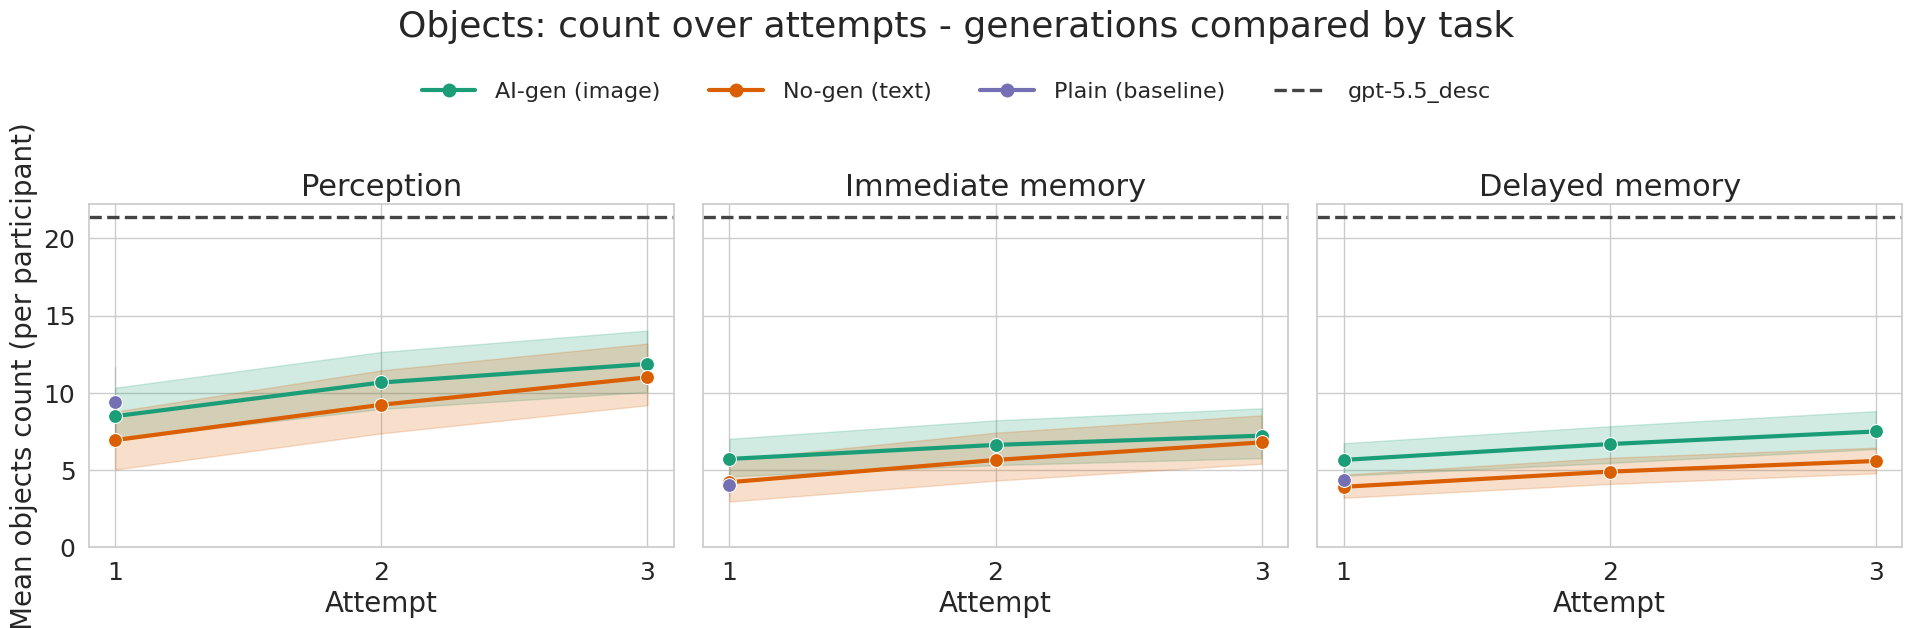

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_stuff_count_over_attempts_by_task.png


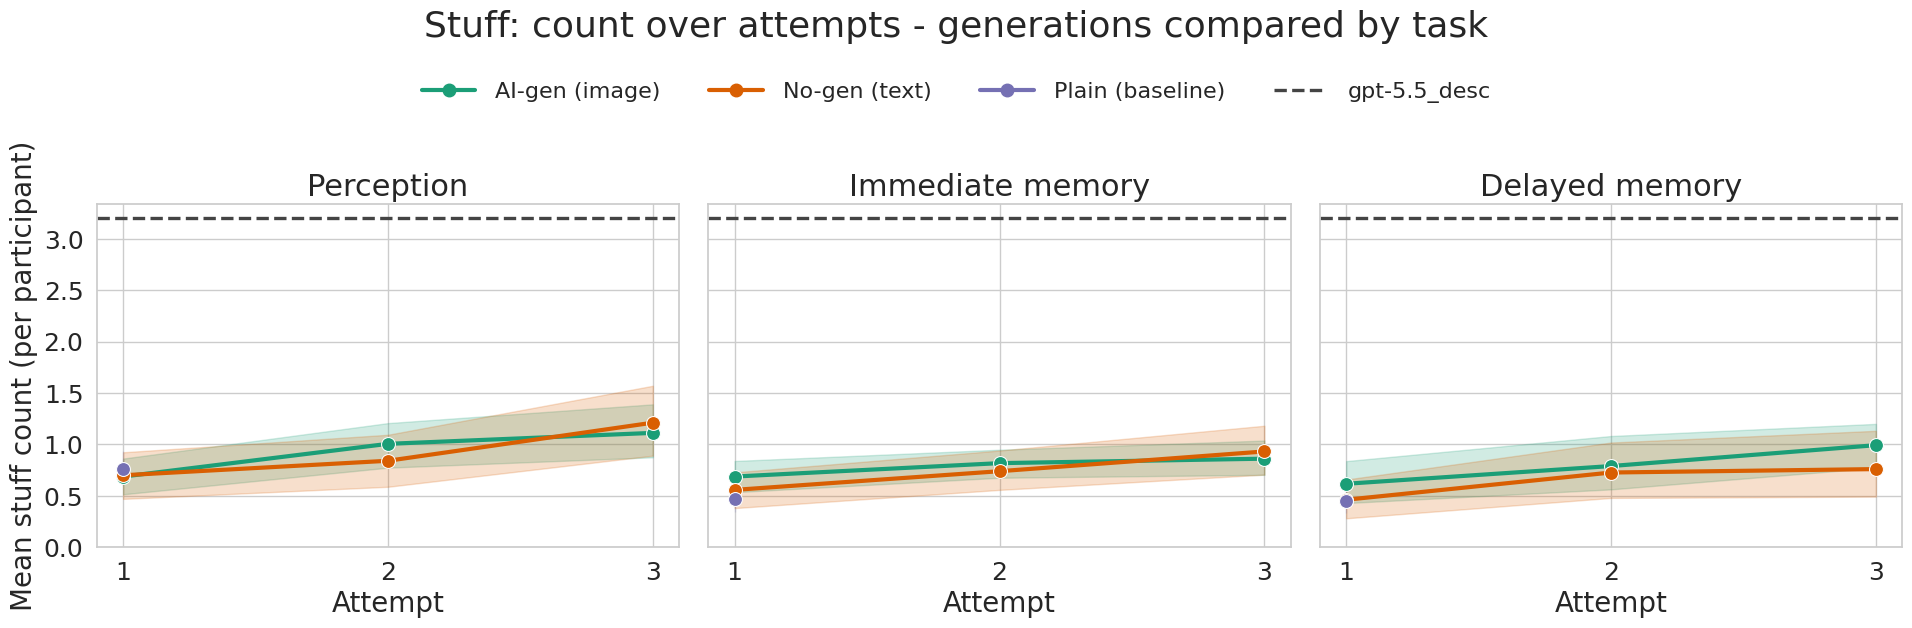

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_scene_category_count_over_attempts_by_task.png


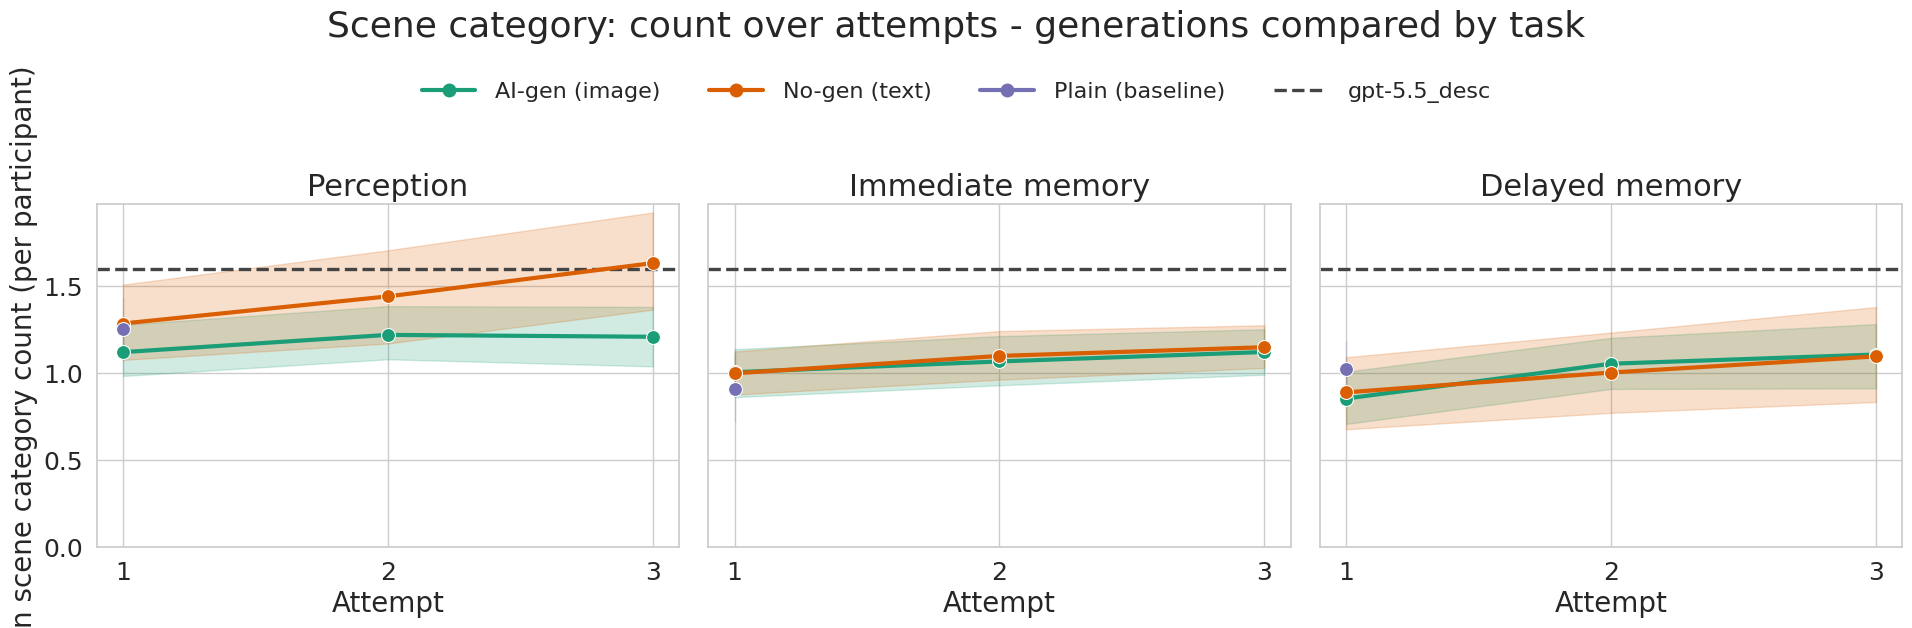

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_spatial_relations_count_over_attempts_by_task.png


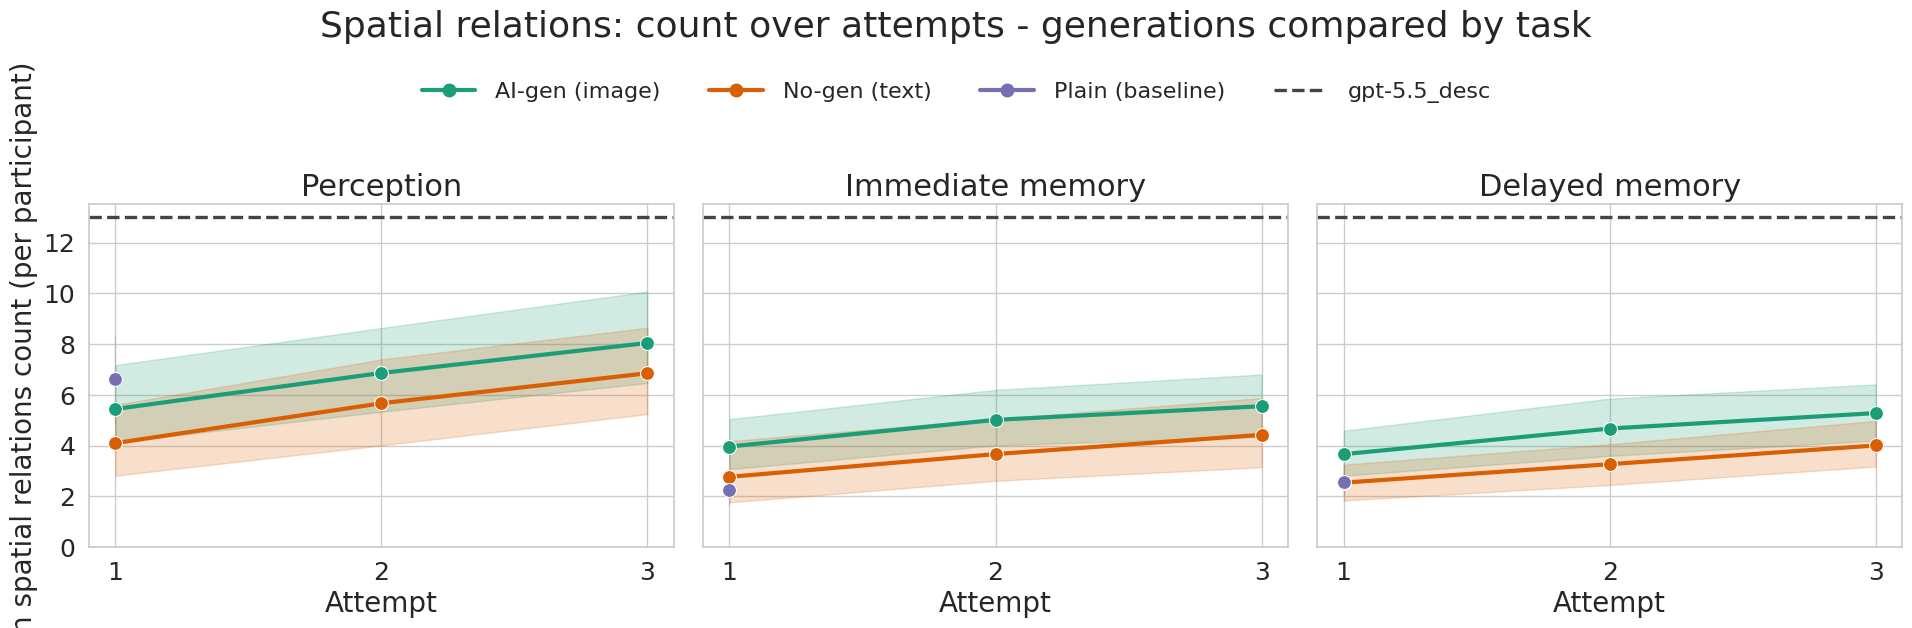

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_attr_color_count_over_attempts_by_task.png


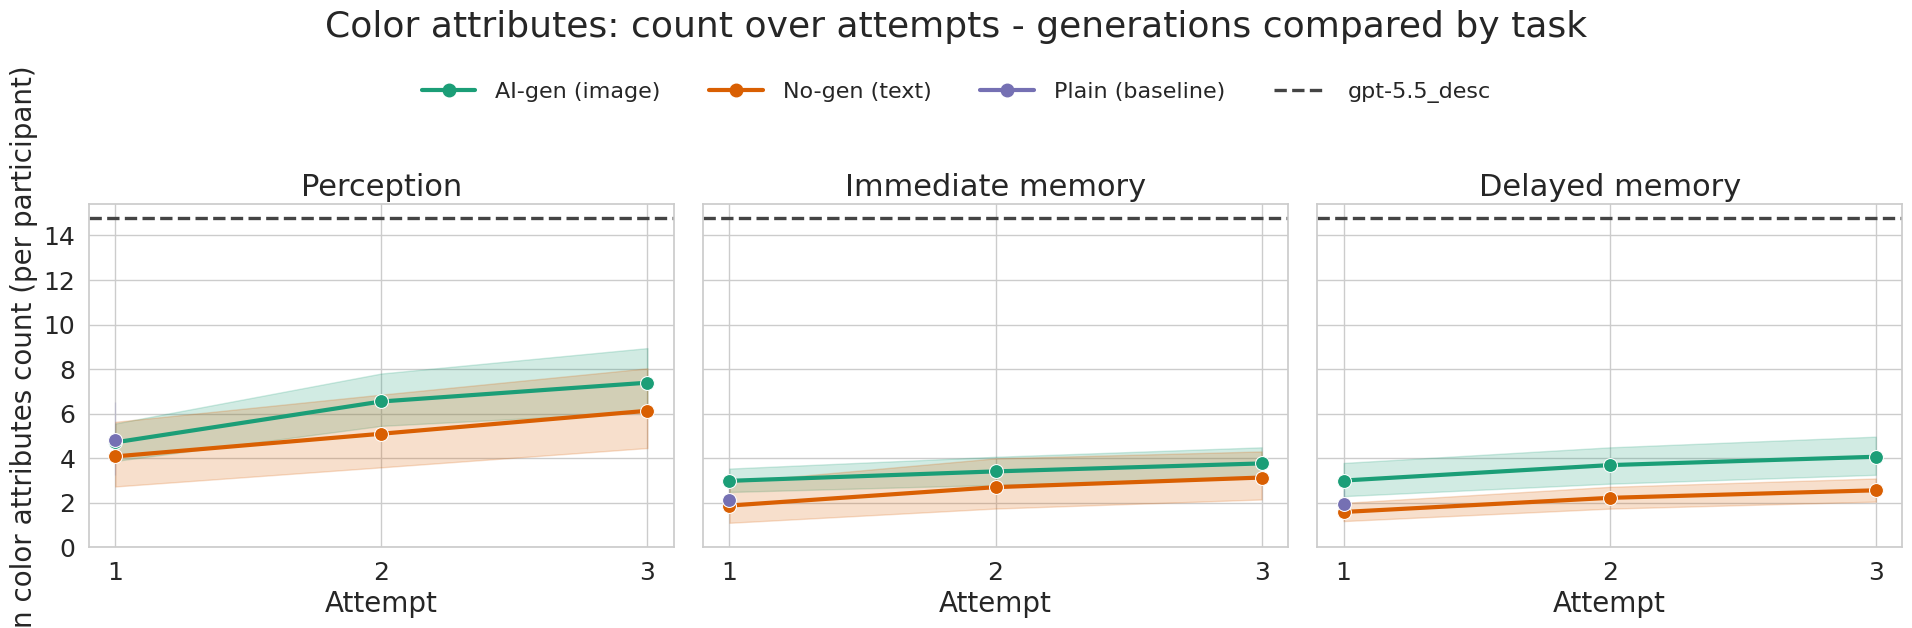

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_adjectives_count_over_attempts_by_task.png


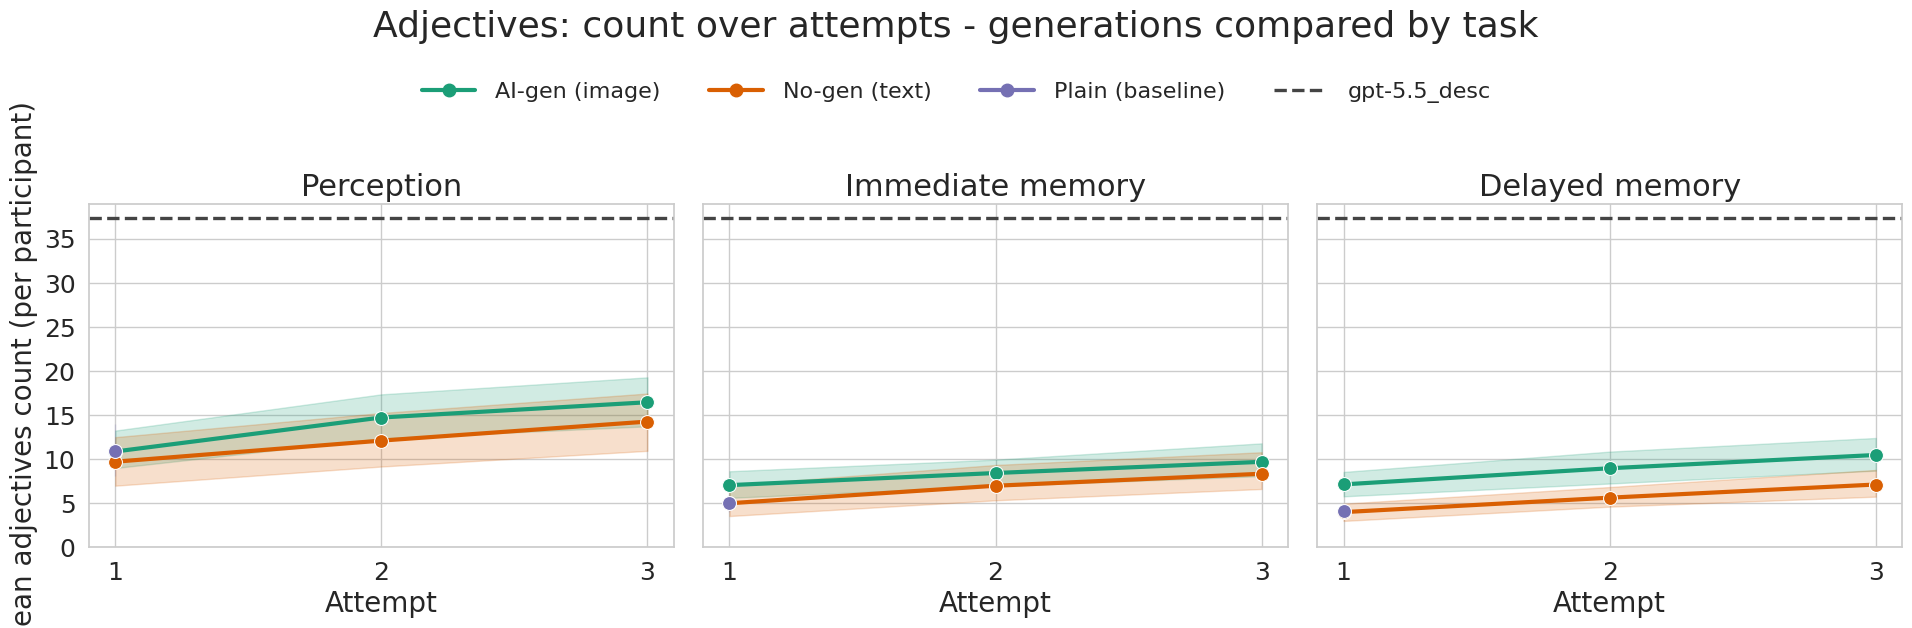

In [52]:
for category in CATEGORIES:
    plot_generations_over_attempts_by_task(category)

## View 1b - same data as bars
Identical numbers to View 1 (per-participant means, mean +/- 95% CI), drawn as grouped bars
instead of lines: one panel per task, x = attempt, one bar per generation. Bars make the
level differences between feedback types easier to read at a glance; the lines above make the
trend across attempts easier. The dashed line is `gpt-5.5_desc`.

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_objects_count_over_attempts_by_task_bars.png


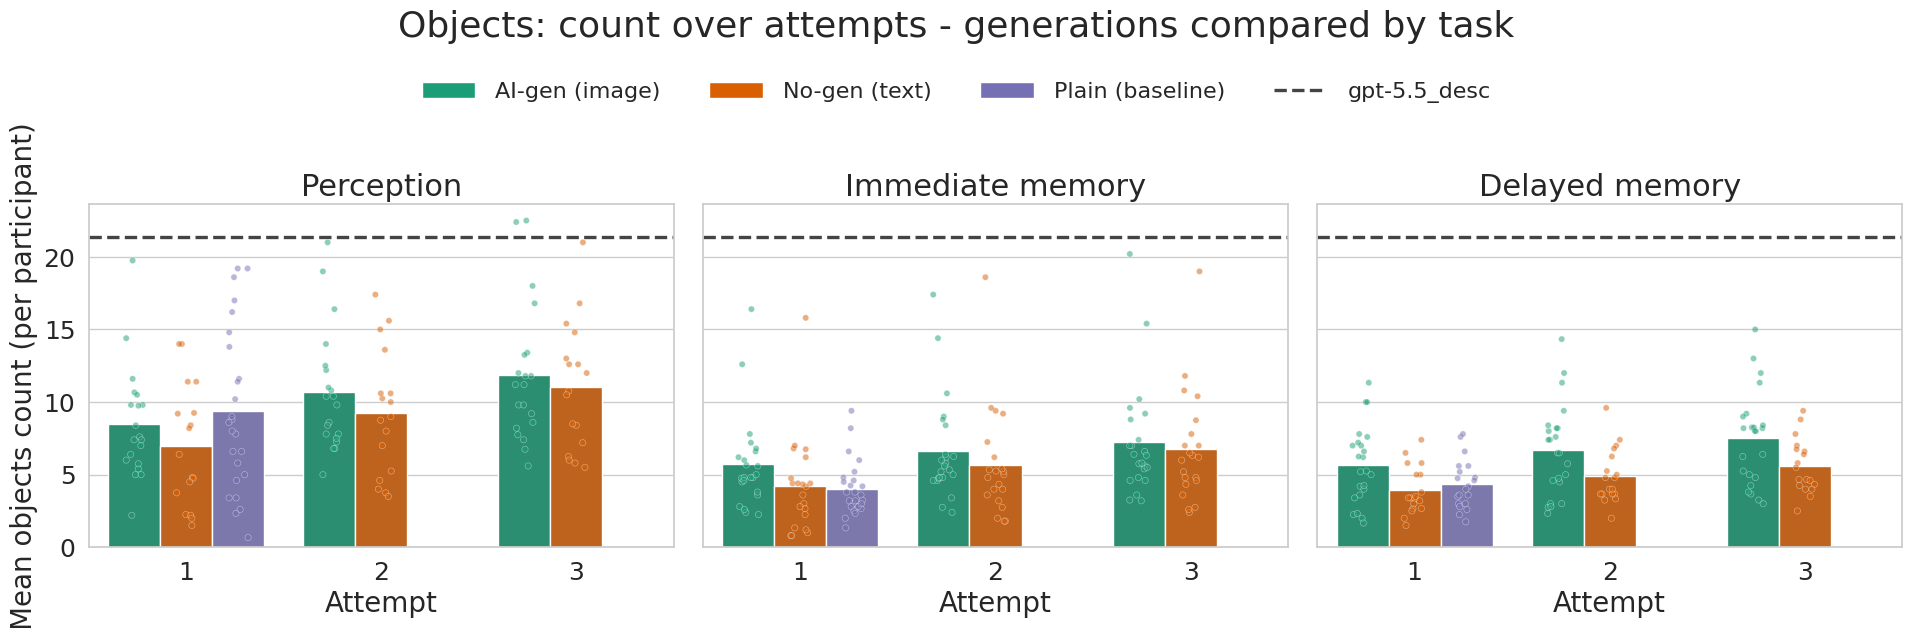

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_stuff_count_over_attempts_by_task_bars.png


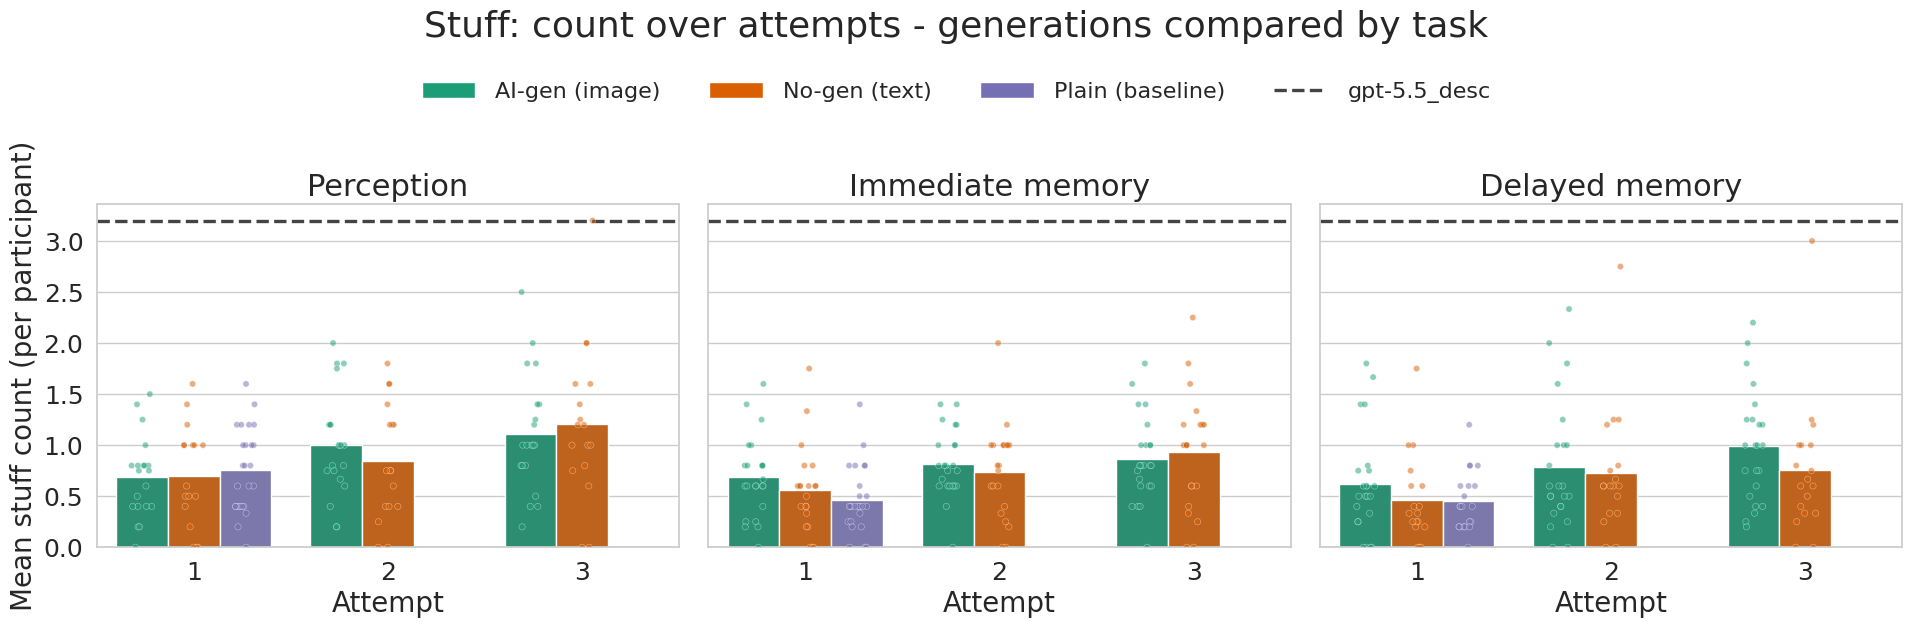

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_scene_category_count_over_attempts_by_task_bars.png


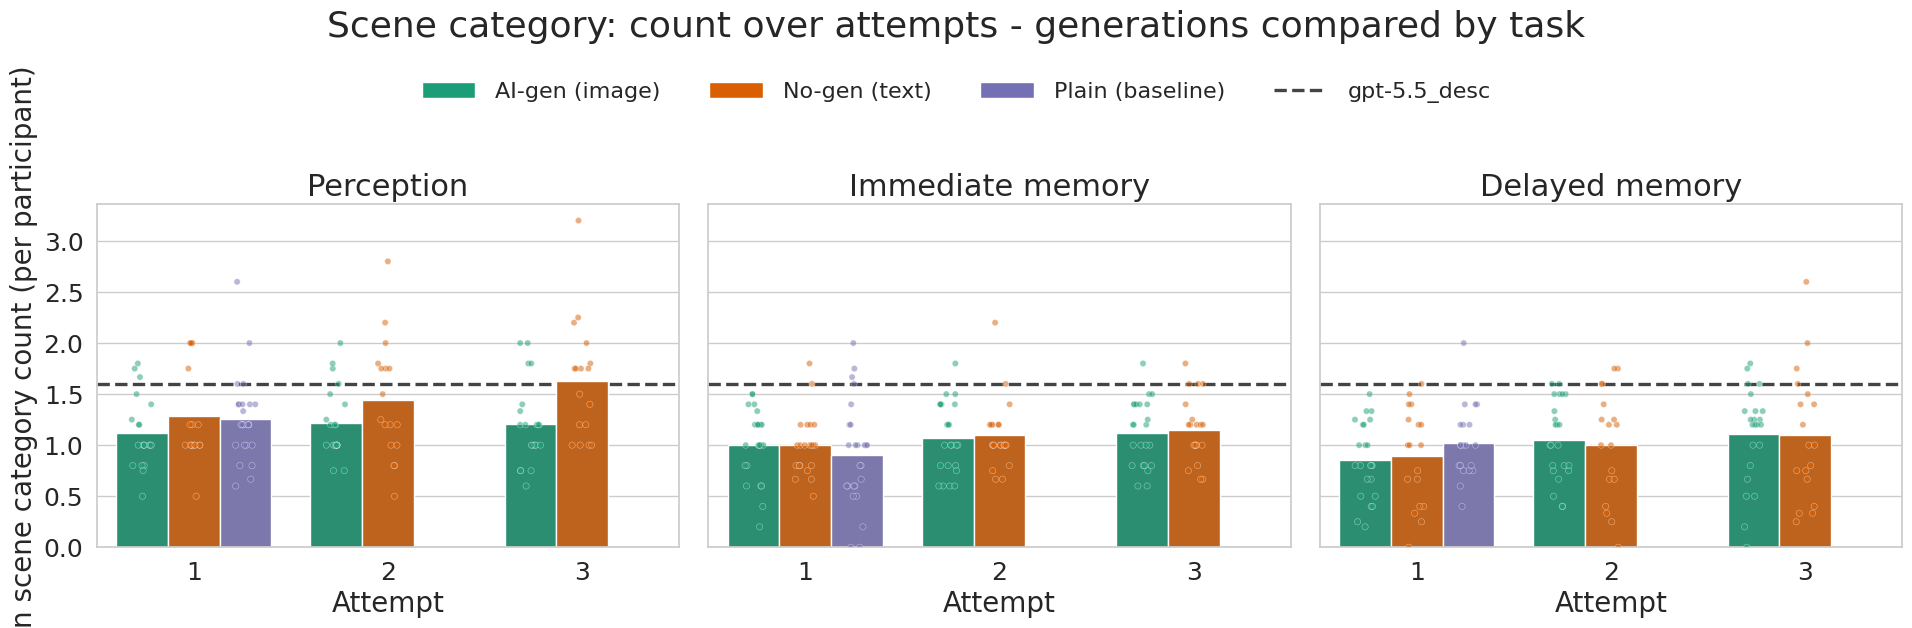

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_spatial_relations_count_over_attempts_by_task_bars.png


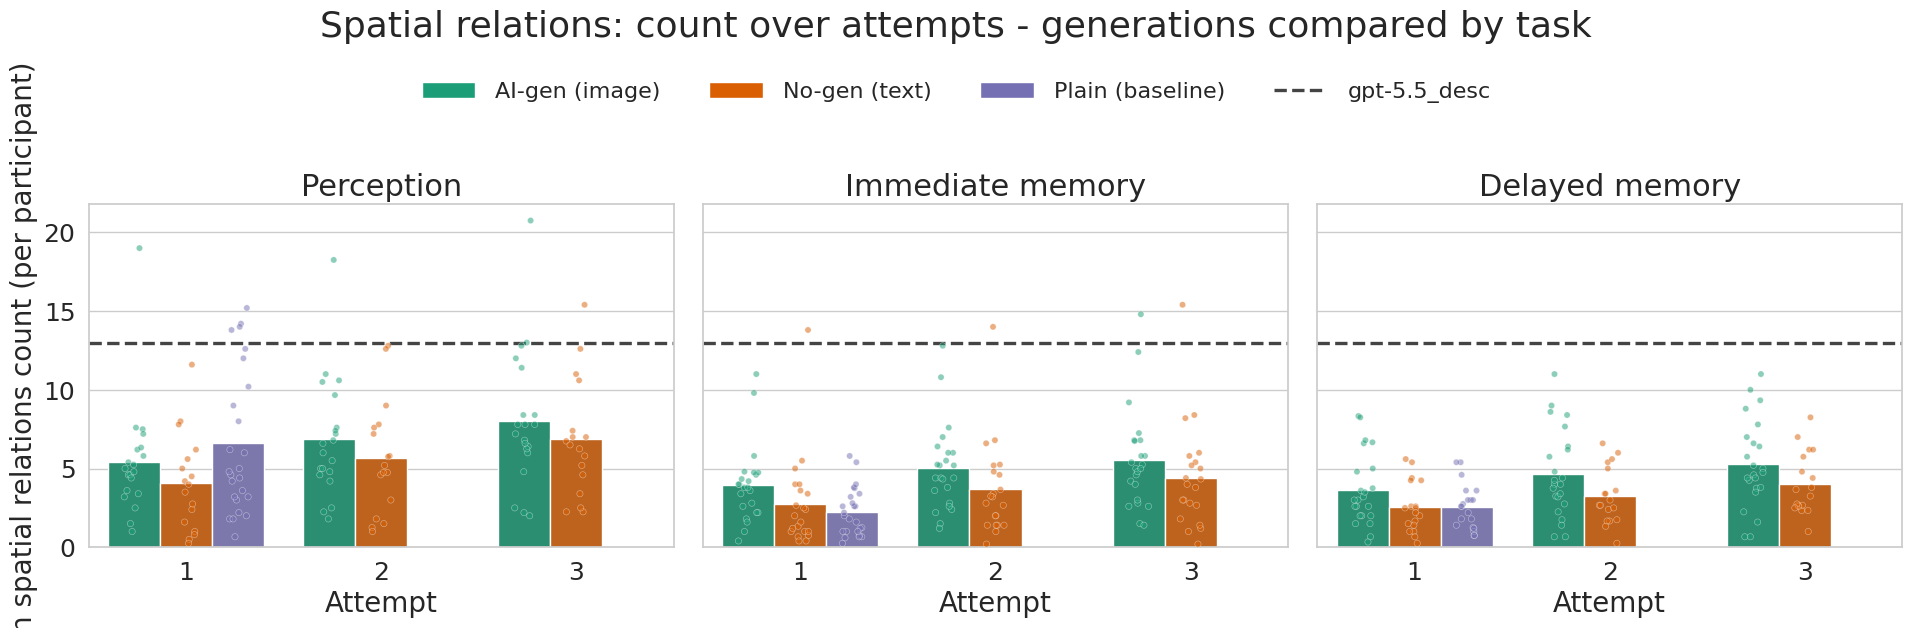

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_attr_color_count_over_attempts_by_task_bars.png


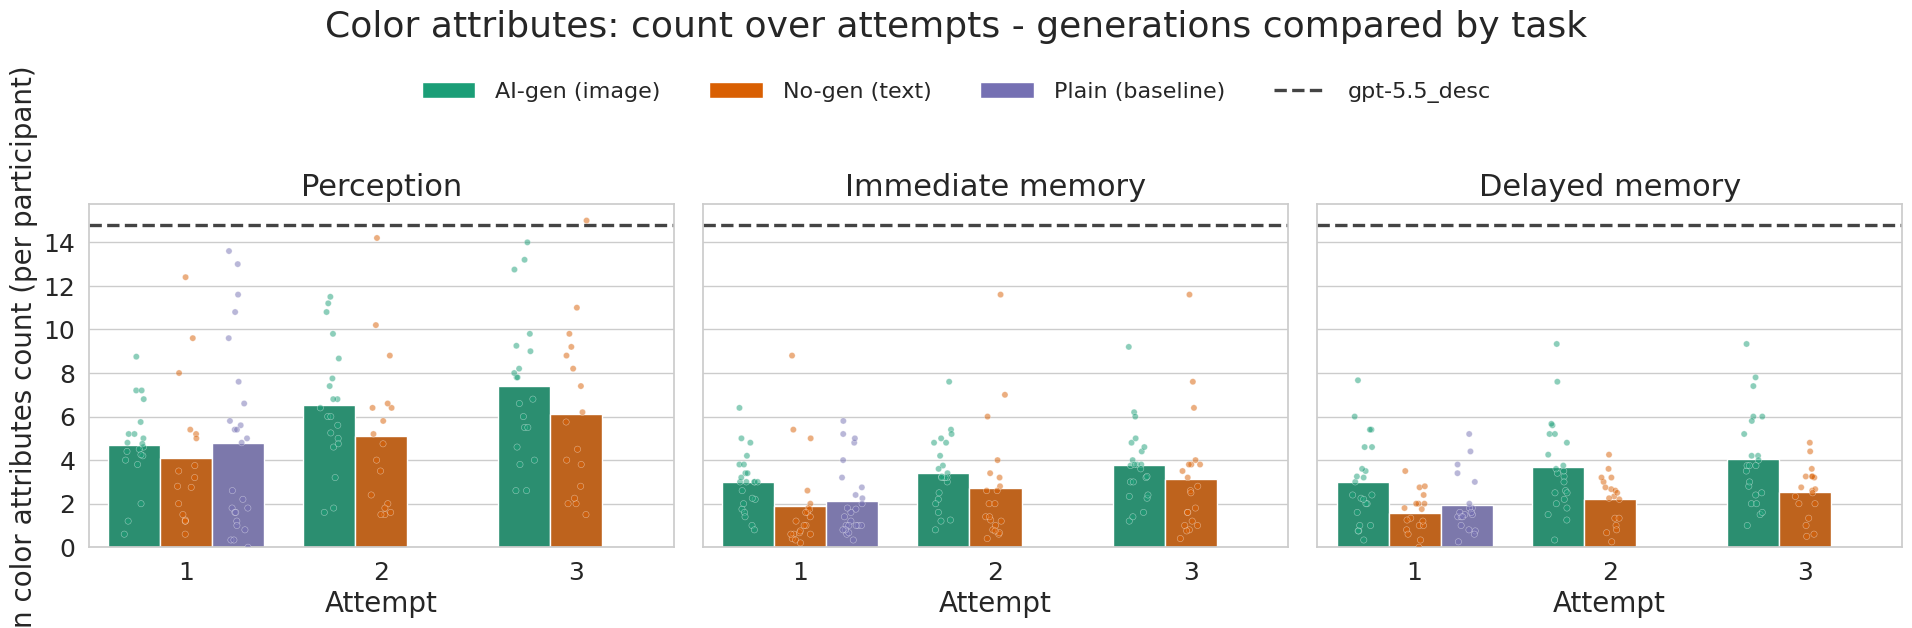

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_adjectives_count_over_attempts_by_task_bars.png


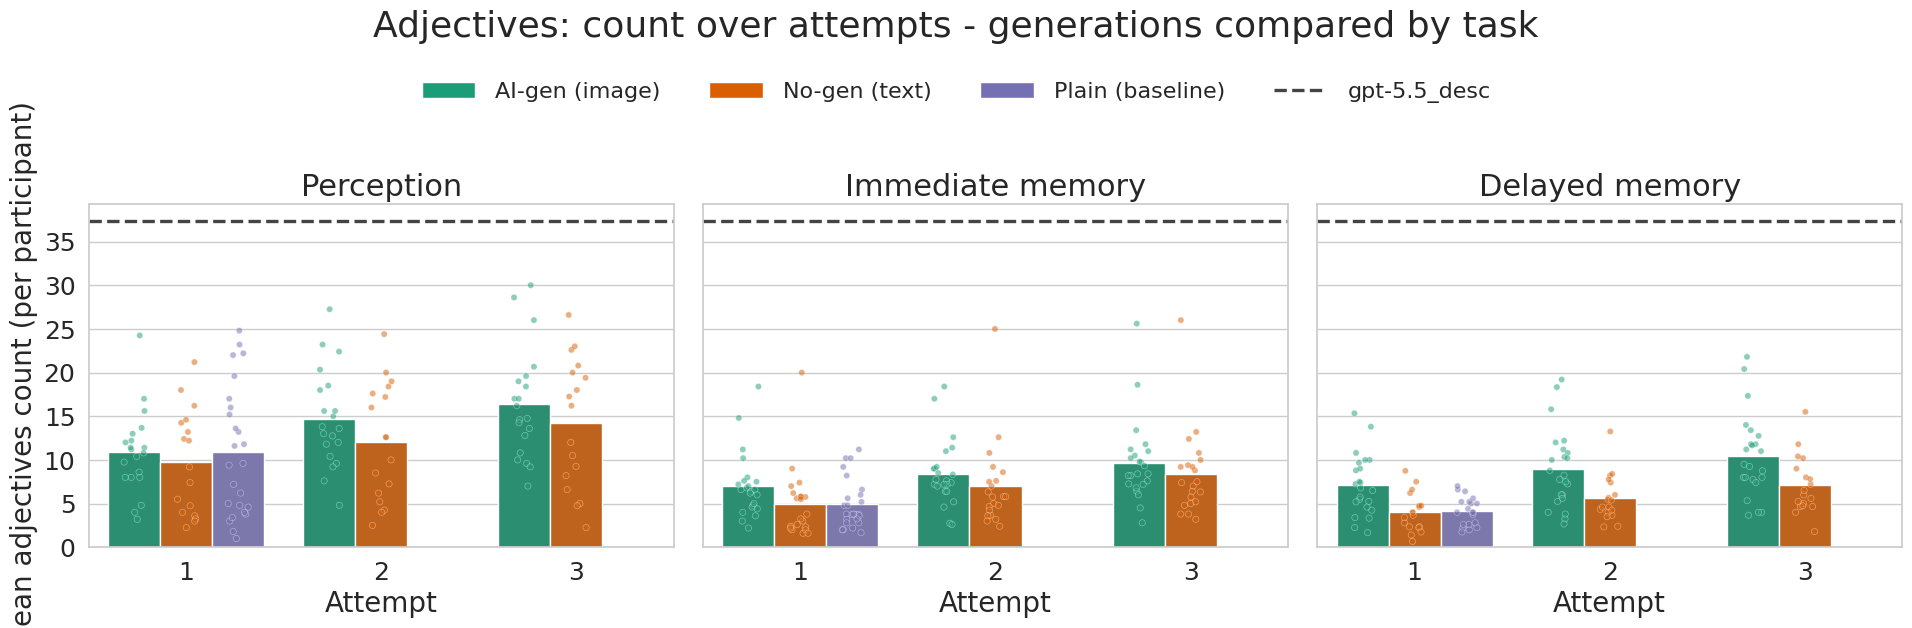

In [53]:
def plot_generations_over_attempts_bars(category, save=True):
    """VIEW 1b: View 1's data as grouped bars - one panel per task, x = attempt,
    one bar per generation (participant means as dots, no error bars)."""
    label = CATEGORIES[category]
    g = _ppt_attempt_means(category)
    # Shared y range across panels: the tallest dot, or the gpt-5.5_desc line if it is higher.
    vmax = max(g["count"].max(), GPT_DESC.get(category, 0))
    fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(6.5 * len(TASK_ORDER), 6.5),
                             sharey=True)
    axes = np.atleast_1d(axes)
    for i, (ax, task) in enumerate(zip(axes, TASK_ORDER)):
        sub = g[g["task"] == task]
        if not sub.empty:
            sns.barplot(data=sub, x="attempt", y="count", hue="generation",
                        order=ATTEMPTS, hue_order=GEN_ORDER, palette=GEN_COLORS,
                        errorbar=None, legend=False, ax=ax, zorder=2)
            # One dot per participant, dodged onto its own bar.
            sns.stripplot(data=sub, x="attempt", y="count", hue="generation",
                          order=ATTEMPTS, hue_order=GEN_ORDER, palette=GEN_COLORS,
                          dodge=True, jitter=0.16, size=4.5, alpha=0.5, linewidth=0.4,
                          edgecolor="white", legend=False, ax=ax, zorder=3)
        _add_gpt_desc(ax, category)
        ax.set_title(TASK_LABELS[task])
        ax.set_xlabel("Attempt")
        ax.set_ylabel(f"Mean {label.lower()} count (per participant)" if i == 0 else "")
        _style_count_axis(ax, vmax=vmax)
    fig.suptitle(f"{label}: count over attempts - generations compared by task")
    _figure_legend(fig, marker="bar")
    fig.tight_layout(rect=(0, 0, 1, 0.87))
    if save:
        _save(fig, GRAPHS / f"crossgen_{category}_count_over_attempts_by_task_bars.png")
    plt.show()


for category in CATEGORIES:
    plot_generations_over_attempts_bars(category)

## View 1c - all categories within one task
Flips the layout of View 1b: **one figure per task** (perception, then immediate, then delay),
and inside it every semantic category side by side, one bar per generation. Answers "what does
a description in *this* condition contain", where 1/1b answer "how does *this* category behave
across conditions".

Raw counts, with participant means as dots and `gpt-5.5_desc` as a dashed cap over each
category. Counts are collapsed across attempts by default (per-participant mean); pass
`attempt=3` for the last attempt only.

Note the categories differ by an order of magnitude (adjectives ~14 vs scene_category ~1), so
the small ones sit near the floor of a shared axis - read each category against its own dashed
cap rather than against the other categories.

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_all_categories_perception_all_attempts.png


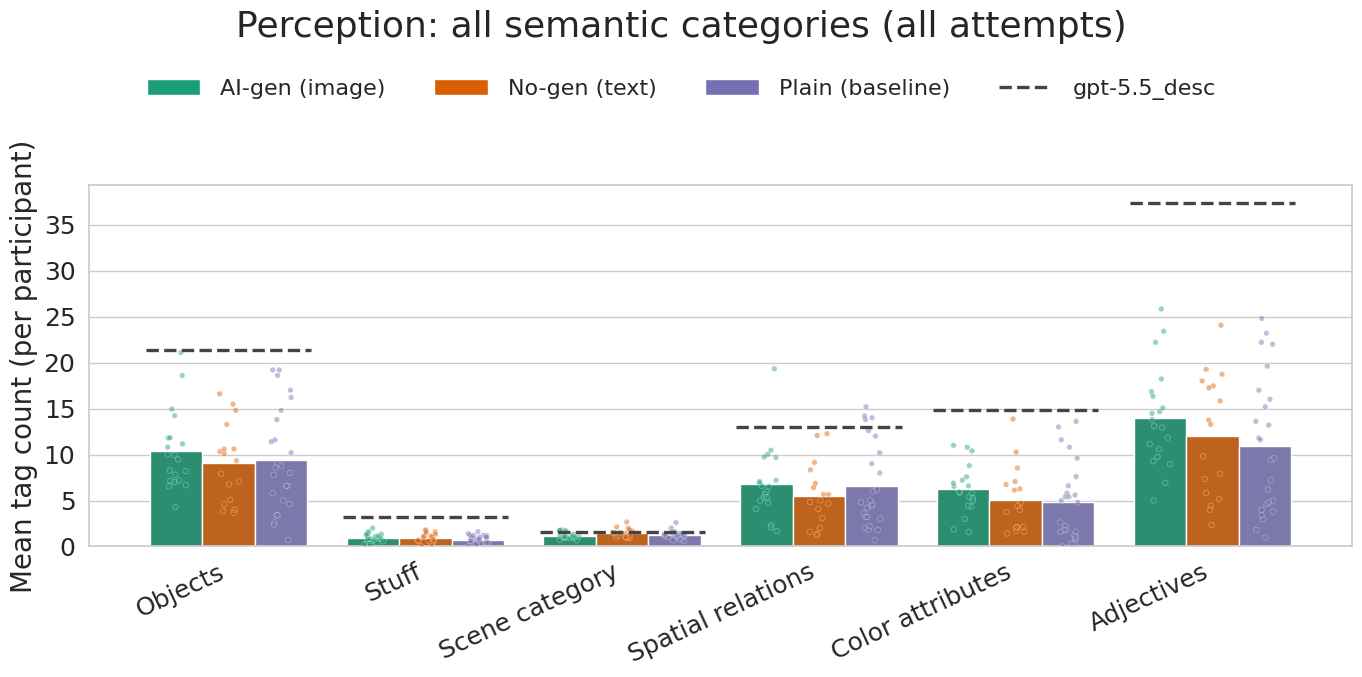

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_all_categories_immediate_all_attempts.png


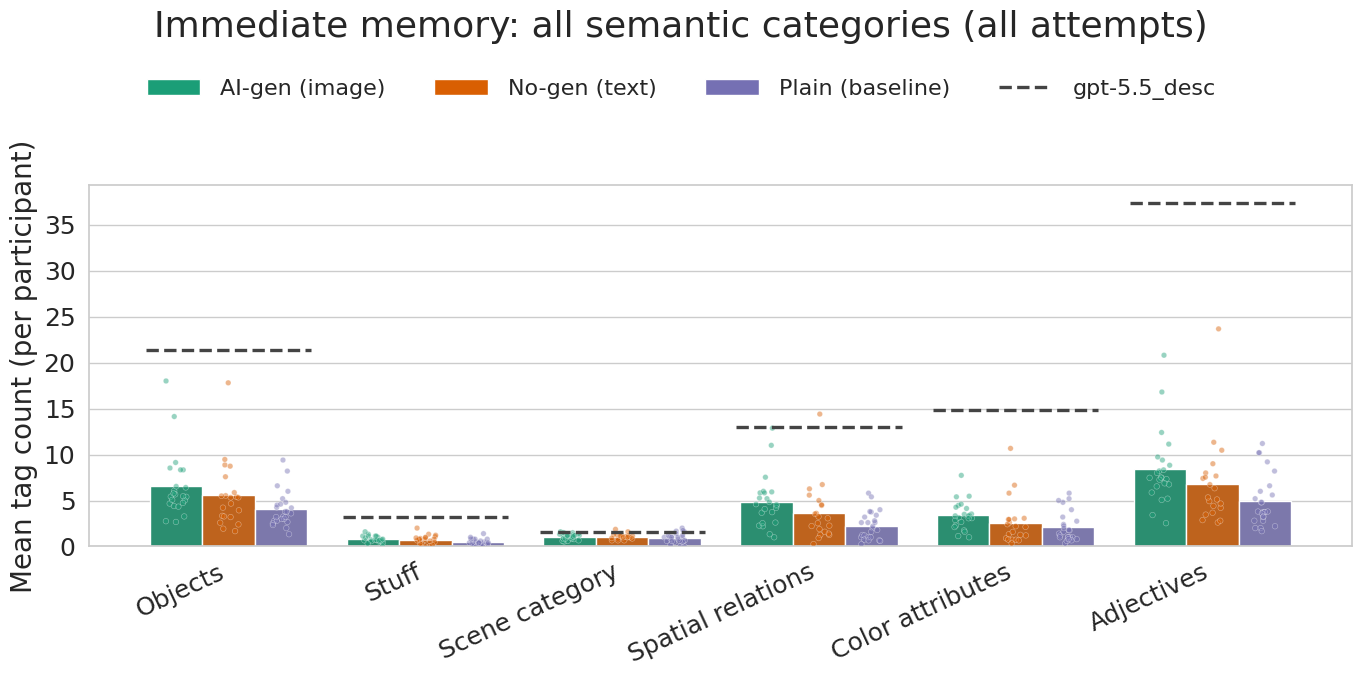

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_all_categories_delay_all_attempts.png


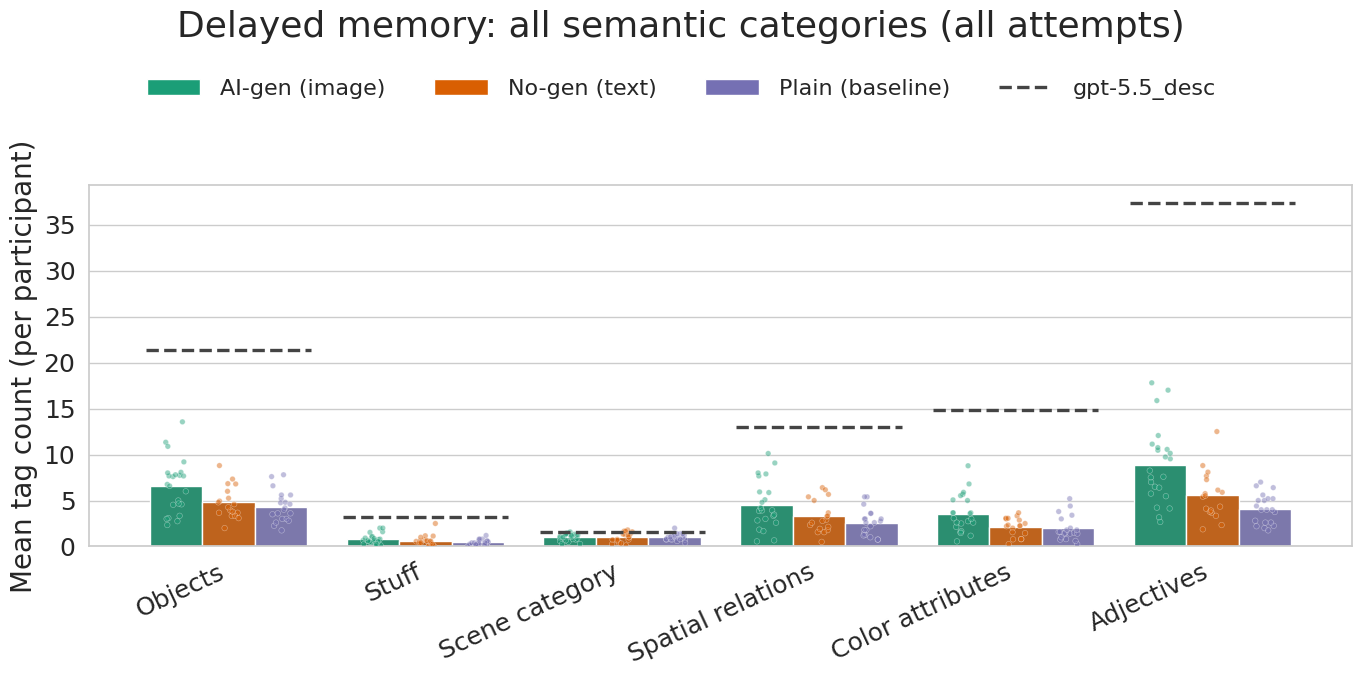

In [54]:
def _ppt_means_by_task(task, attempt=None):
    """Per-participant mean count in every category for one task, melted long.
    attempt=None collapses attempts; an int keeps only that attempt."""
    cols = [f"n_{c}" for c in CATEGORIES]
    d = df[df["task"] == task]
    if attempt is not None:
        d = d[d["attempt"] == attempt]
    per_ppt = d.groupby(["generation", "uid"], as_index=False)[cols].mean()
    long = per_ppt.melt(id_vars=["generation", "uid"], value_vars=cols,
                        var_name="category", value_name="count")
    long["category"] = long["category"].str.removeprefix("n_")
    return long


def plot_all_categories_for_task(task, attempt=None, save=True):
    """VIEW 1c: one figure for a single task, all semantic categories side by side.
    Bars = mean over participants, dots = individual participants, dashed caps = gpt-5.5_desc."""
    long = _ppt_means_by_task(task, attempt)
    if long.empty:
        print(f"{task}: no rows - skipping")
        return
    cats = list(CATEGORIES)
    labels = [CATEGORIES[c] for c in cats]
    gens = [g for g in GEN_ORDER if g in set(long["generation"])]

    fig, ax = plt.subplots(figsize=(14, 7.0))
    sns.barplot(data=long, x="category", y="count", hue="generation",
                order=cats, hue_order=gens, palette=GEN_COLORS,
                errorbar=None, legend=False, ax=ax, zorder=2)
    sns.stripplot(data=long, x="category", y="count", hue="generation",
                  order=cats, hue_order=gens, palette=GEN_COLORS,
                  dodge=True, jitter=0.16, size=4.0, alpha=0.45, linewidth=0.4,
                  edgecolor="white", legend=False, ax=ax, zorder=3)
    for i, cat in enumerate(cats):
        if cat in GPT_DESC:
            ax.plot([i - 0.42, i + 0.42], [GPT_DESC[cat]] * 2, color=GPT_DESC_COLOR,
                    ls="--", lw=2.4, zorder=4)
    ax.set_xlabel(""); ax.set_ylabel("Mean tag count (per participant)")
    ax.set_xticks(range(len(cats))); ax.set_xticklabels(labels, rotation=25, ha="right")
    _style_count_axis(ax, vmax=max(long["count"].max(),
                                   max(GPT_DESC.values()) if GPT_DESC else 0))

    att = "all attempts" if attempt is None else f"attempt {attempt}"
    fig.suptitle(f"{TASK_LABELS[task]}: all semantic categories ({att})")
    _figure_legend(fig, marker="bar", y=0.91)
    fig.tight_layout(rect=(0, 0, 1, 0.86))
    if save:
        suffix = "all_attempts" if attempt is None else f"attempt{attempt}"
        _save(fig, GRAPHS / f"crossgen_all_categories_{task}_{suffix}.png")
    plt.show()


for task in TASK_ORDER:
    plot_all_categories_for_task(task)

## View 1d - all categories for one task, panel grid
View 1b's panels (x = attempt, one bar per generation, participant dots, dashed `gpt-5.5_desc`
cap) for **every semantic category at once**, laid out 3 panels per row for a single task -
`perception` by default. Attempts are kept, unlike View 1c which collapses them.

Each panel gets its **own y axis**: the categories differ by an order of magnitude
(adjectives ~14 vs scene_category ~1), so a shared scale would flatten the small ones. Read the
level of each panel against its own dashed cap, not against the neighbouring panels.

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_all_categories_over_attempts_perception.png


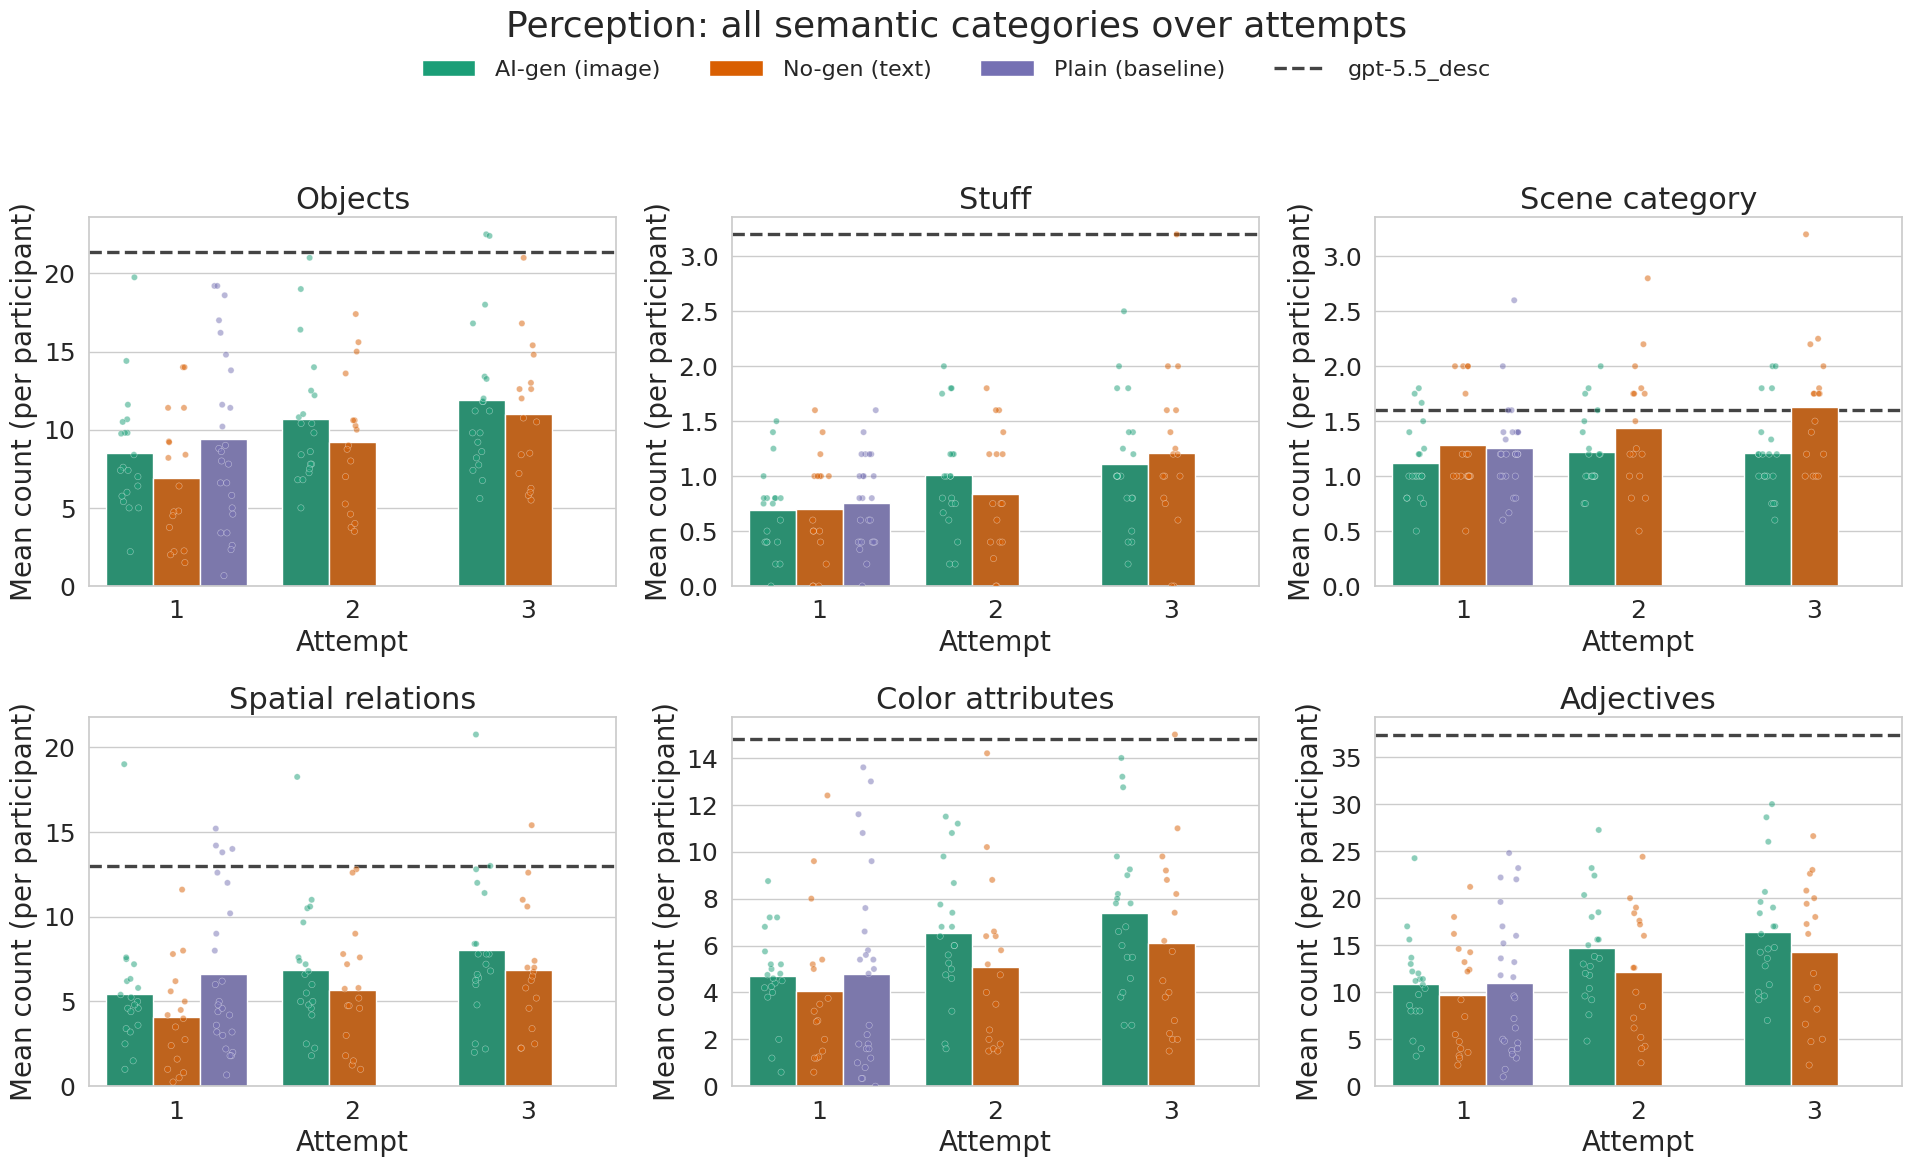

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_all_categories_over_attempts_immediate.png


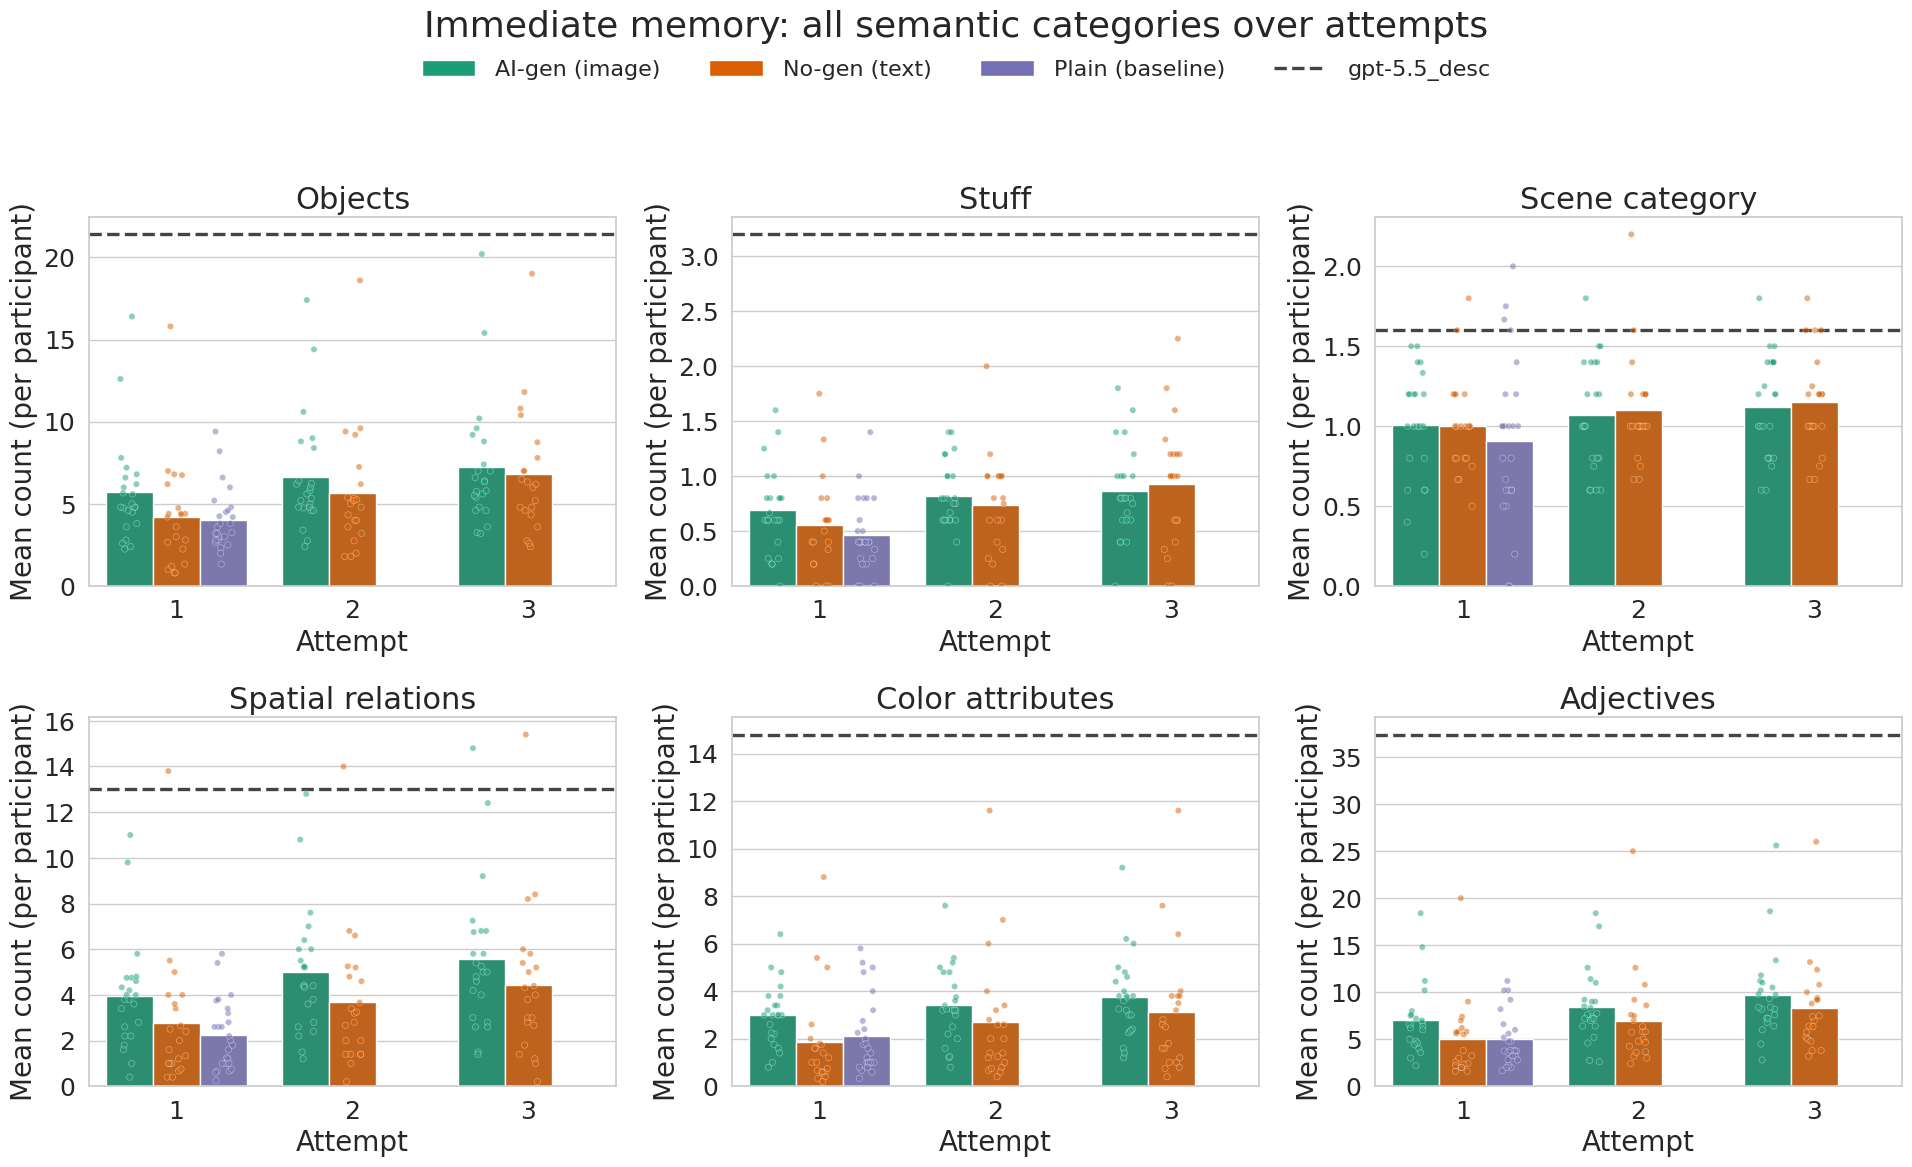

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_all_categories_over_attempts_delay.png


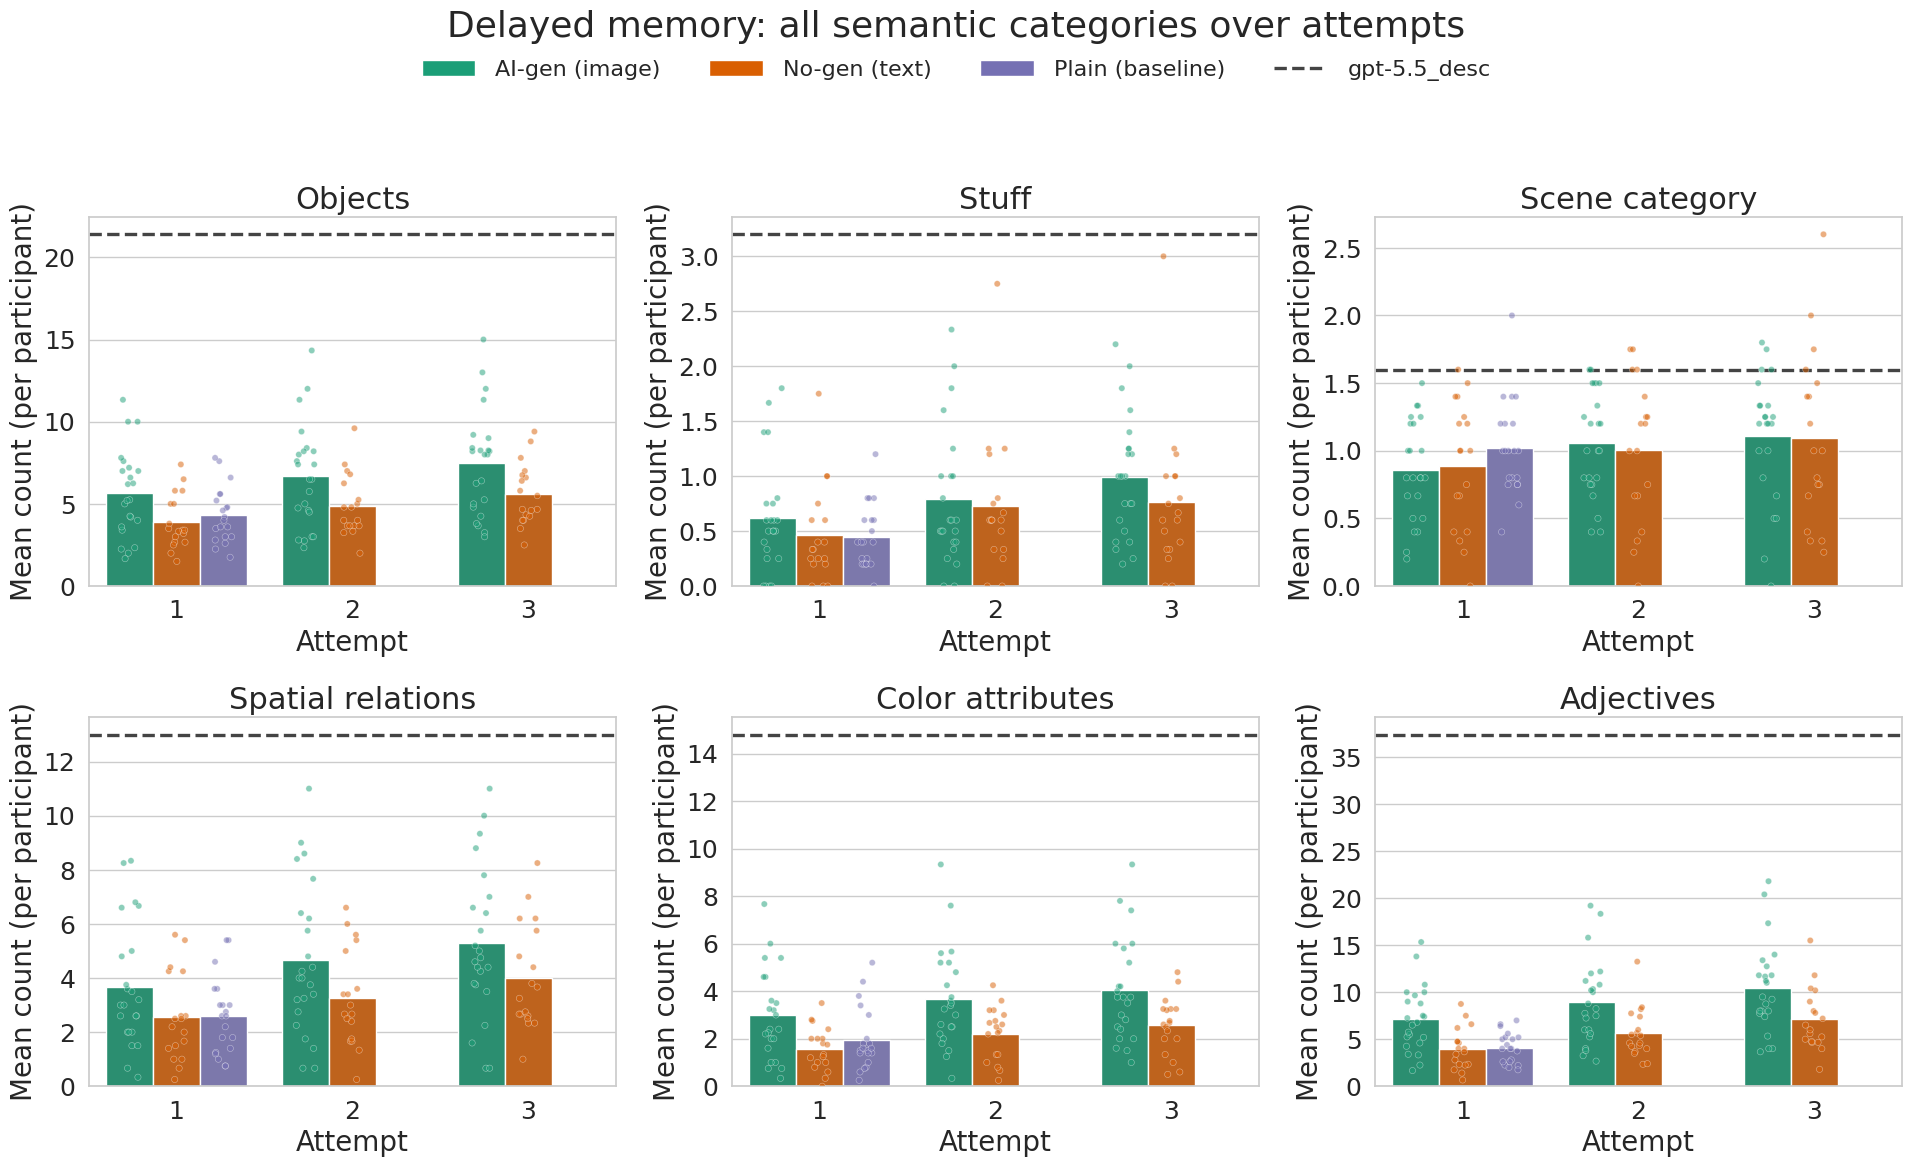

In [56]:
PANEL_COLS = 3  # panels per row in the View 1d grid


def plot_all_categories_over_attempts(task="perception", save=True):
    """VIEW 1d: one figure per task, a grid of per-category panels (PANEL_COLS per row).
    Each panel is View 1b's panel for that category: x = attempt, one bar per generation,
    participant means as dots, dashed gpt-5.5_desc cap. Per-panel y scale."""
    cats = list(CATEGORIES)
    ncol = PANEL_COLS
    nrow = int(np.ceil(len(cats) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6.5 * ncol, 6.0 * nrow))
    axes = np.atleast_1d(axes).ravel()

    for ax, category in zip(axes, cats):
        g = _ppt_attempt_means(category)
        sub = g[g["task"] == task]
        if sub.empty:
            ax.set_visible(False)
            continue
        sns.barplot(data=sub, x="attempt", y="count", hue="generation",
                    order=ATTEMPTS, hue_order=GEN_ORDER, palette=GEN_COLORS,
                    errorbar=None, legend=False, ax=ax, zorder=2)
        sns.stripplot(data=sub, x="attempt", y="count", hue="generation",
                      order=ATTEMPTS, hue_order=GEN_ORDER, palette=GEN_COLORS,
                      dodge=True, jitter=0.16, size=4.5, alpha=0.5, linewidth=0.4,
                      edgecolor="white", legend=False, ax=ax, zorder=3)
        _add_gpt_desc(ax, category)
        ax.set_title(CATEGORIES[category])
        ax.set_xlabel("Attempt")
        ax.set_ylabel("Mean count (per participant)")
        # Own scale per panel - the categories are an order of magnitude apart.
        _style_count_axis(ax, vmax=max(sub["count"].max(), GPT_DESC.get(category, 0)))

    for ax in axes[len(cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{TASK_LABELS[task]}: all semantic categories over attempts")
    _figure_legend(fig, marker="bar", y=0.955)
    fig.tight_layout(rect=(0, 0, 1, 0.91))
    if save:
        _save(fig, GRAPHS / f"crossgen_all_categories_over_attempts_{task}.png")
    plt.show()


for task in TASK_ORDER:
    plot_all_categories_over_attempts(task)


## View 2 - improvement delta (attempt 3 - attempt 1) by condition
How much does the count change across the feedback loop, and does that depend on the feedback /
generation type? Per participant we take the mean count at attempt 3 minus attempt 1
(positive = more tags by the last attempt). Bars = mean +/- SE, x = task, color = generation,
faint points = individual participants; the dashed line marks no change.

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_objects_count_improvement_delta.png


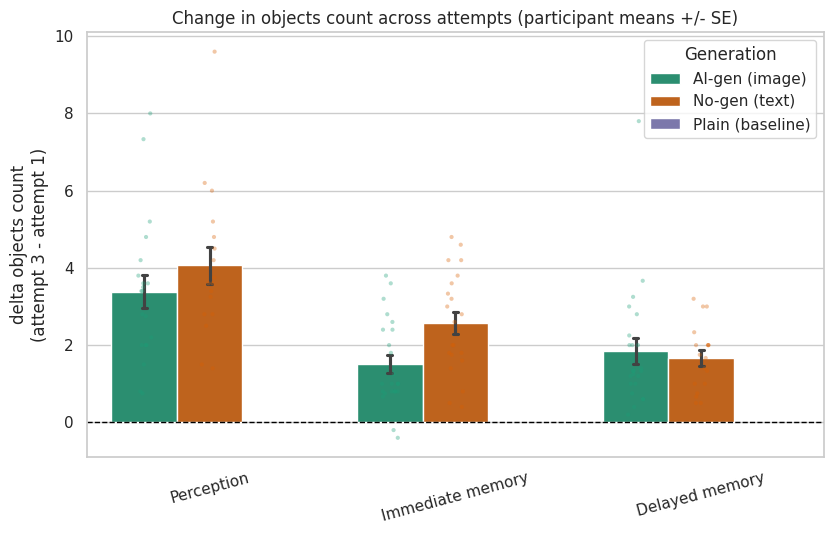

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_stuff_count_improvement_delta.png


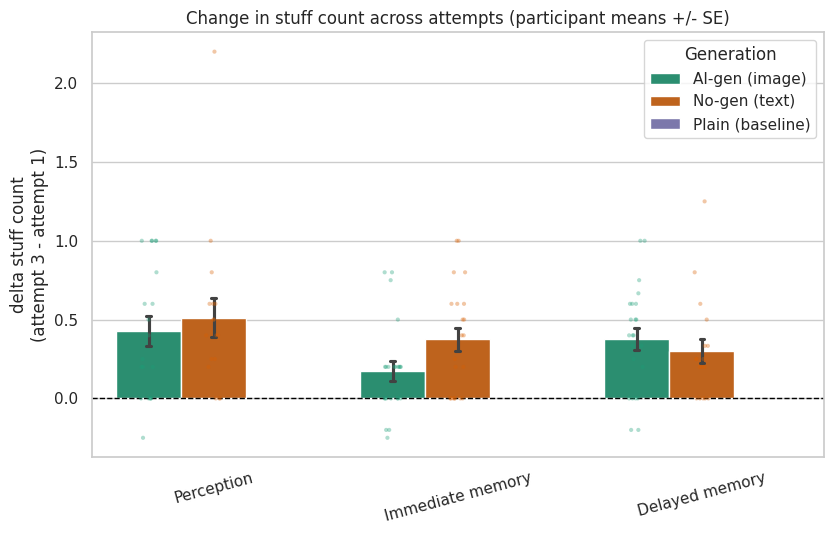

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_scene_category_count_improvement_delta.png


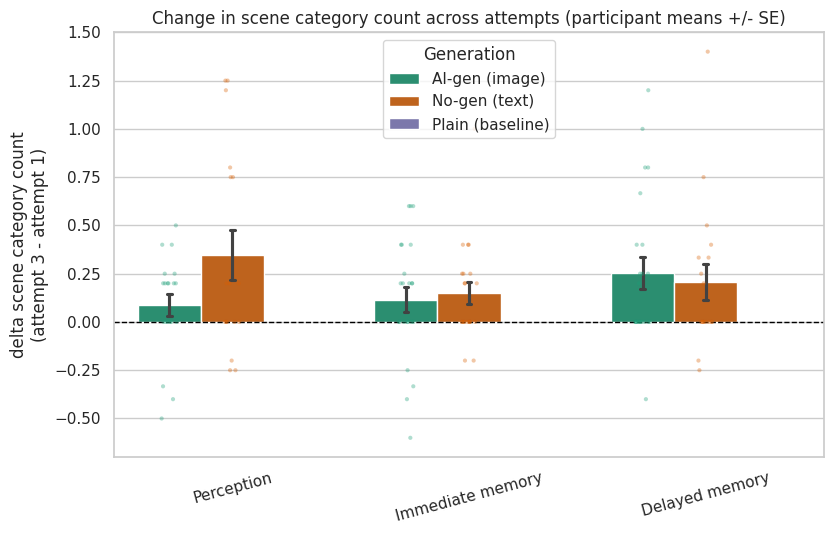

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_spatial_relations_count_improvement_delta.png


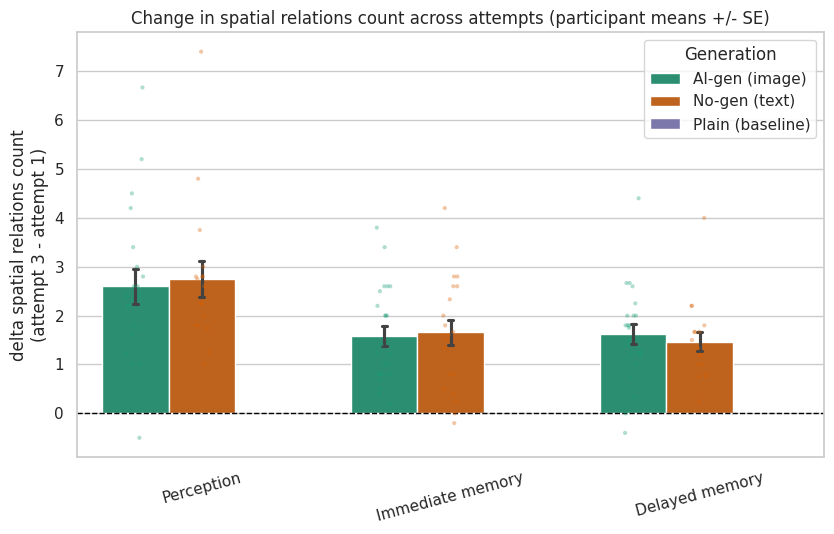

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_attr_color_count_improvement_delta.png


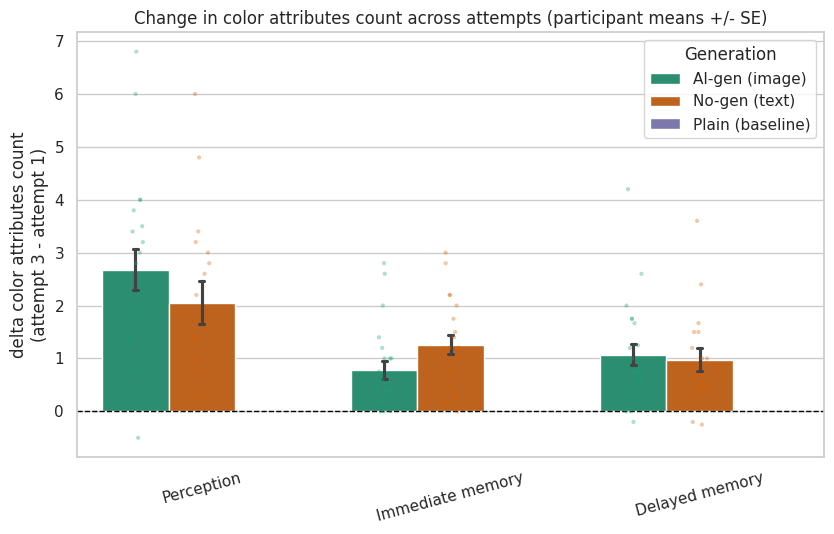

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs/nlp_graphs/crossgen_adjectives_count_improvement_delta.png


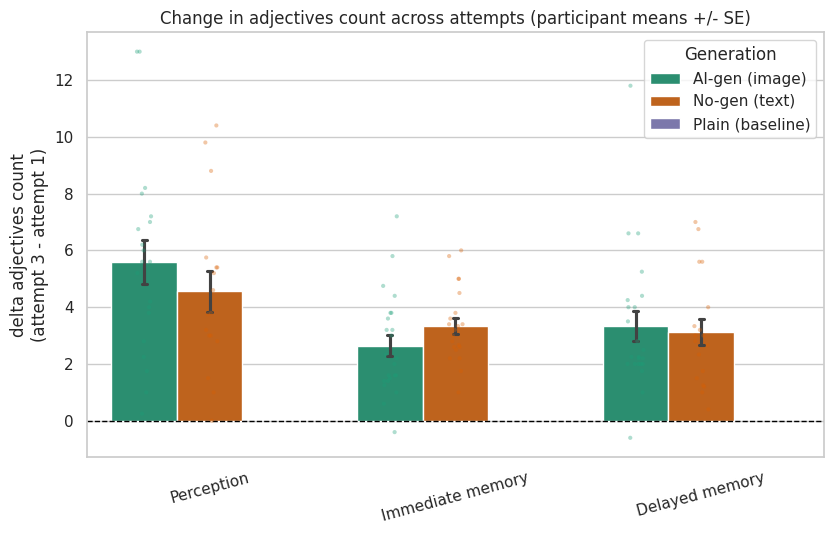

In [6]:
def plot_improvement_delta_bars(category, save=True):
    """Improvement delta = per-participant mean(attempt 3) - mean(attempt 1), one bar per
    (generation x task). x = task, hue/dodge = generation, faint per-participant points overlaid."""
    label = CATEGORIES[category]
    pm = _ppt_attempt_means(category)
    wide = pm.pivot_table(index=["generation", "task", "uid"], columns="attempt", values="count")
    if not {1, 3}.issubset(wide.columns):
        print(f"{category}: missing attempt 1 or 3 - skipping")
        return
    wide = wide.dropna(subset=[1, 3])
    d = (wide[3] - wide[1]).rename("delta").reset_index()

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    sns.barplot(data=d, x="task", y="delta", hue="generation",
                order=TASK_ORDER, hue_order=GEN_ORDER,
                palette=GEN_COLORS, errorbar="se", capsize=0.06, ax=ax)
    sns.stripplot(data=d, x="task", y="delta", hue="generation",
                  order=TASK_ORDER, hue_order=GEN_ORDER,
                  palette=GEN_COLORS, dodge=True, size=3, alpha=0.35,
                  linewidth=0, ax=ax, legend=False)
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_xlabel(""); ax.set_ylabel(f"delta {label.lower()} count\n(attempt 3 - attempt 1)")
    ax.set_xticks(range(len(TASK_ORDER)))
    ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER], rotation=15)
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles[:len(GEN_ORDER)], [GEN_LABELS[g] for g in GEN_ORDER],
              title="Generation", frameon=True)
    ax.set_title(f"Change in {label.lower()} count across attempts (participant means +/- SE)")
    fig.tight_layout()
    if save:
        out = GRAPHS / f"crossgen_{category}_count_improvement_delta.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()


for category in CATEGORIES:
    plot_improvement_delta_bars(category)

## View 3 - humans vs gpt-5.5_desc
How far below `gpt-5.5_desc` do participants sit, and does that gap depend on generation type?
`gpt-5.5_desc` is one GPT description per ground-truth image, written *with the image in view*
and tagged by the same tagger — so any shortfall is about what people say, not about how the
tags are counted.

Left panel: raw mean counts per generation (bars, mean of per-participant means +/- SE) with
`gpt-5.5_desc` as a dashed line per category. Right panel: the same as **% of gpt-5.5_desc**,
which puts all six categories on one scale (100% = as many tags as GPT extracted from the
image itself).

In [ ]:
def _ppt_means_all_categories():
    """One row per (generation, uid) with the participant's mean count in each category,
    collapsing tasks/sessions/attempts, then melted long for plotting."""
    cols = [f"n_{c}" for c in CATEGORIES]
    per_ppt = df.groupby(["generation", "uid"], as_index=False)[cols].mean()
    long = per_ppt.melt(id_vars=["generation", "uid"], value_vars=cols,
                        var_name="category", value_name="count")
    long["category"] = long["category"].str.removeprefix("n_")
    return long


def plot_humans_vs_gpt_desc(save=True):
    """VIEW 3: mean counts per generation against gpt-5.5_desc - raw and as a % of it."""
    if not GPT_DESC:
        print("no gpt-5.5_desc loaded - run analysis/gpt_image_desc_api.py first")
        return
    long = _ppt_means_all_categories()
    cats = list(CATEGORIES)
    labels = [CATEGORIES[c] for c in cats]

    fig, (ax_raw, ax_pct) = plt.subplots(1, 2, figsize=(17, 6))

    # Left: raw counts, with one dashed gpt-5.5_desc segment above each category group.
    sns.barplot(data=long, x="category", y="count", hue="generation",
                order=cats, hue_order=GEN_ORDER, palette=GEN_COLORS,
                errorbar="se", capsize=0.06, ax=ax_raw)
    for i, cat in enumerate(cats):
        ax_raw.plot([i - 0.42, i + 0.42], [GPT_DESC[cat]] * 2, color=GPT_DESC_COLOR,
                    ls="--", lw=2, label=GPT_DESC_LABEL if i == 0 else None)
    ax_raw.set_xlabel(""); ax_raw.set_ylabel("Mean tag count (per participant)")
    ax_raw.set_xticks(range(len(cats))); ax_raw.set_xticklabels(labels, rotation=20, ha="right")
    ax_raw.set_title(f"Raw counts vs {GPT_DESC_LABEL}")
    handles, _ = ax_raw.get_legend_handles_labels()
    ax_raw.legend(handles, [GEN_LABELS[g] for g in GEN_ORDER] + [GPT_DESC_LABEL],
                  frameon=True, fontsize=8)

    # Right: same numbers as a share of gpt-5.5_desc, so all categories share one axis.
    pct = long.copy()
    pct["pct"] = 100 * pct["count"] / pct["category"].map(GPT_DESC)
    sns.barplot(data=pct, x="category", y="pct", hue="generation",
                order=cats, hue_order=GEN_ORDER, palette=GEN_COLORS,
                errorbar="se", capsize=0.06, ax=ax_pct)
    ax_pct.axhline(100, color=GPT_DESC_COLOR, ls="--", lw=2, label=GPT_DESC_LABEL)
    ax_pct.set_xlabel(""); ax_pct.set_ylabel(f"% of {GPT_DESC_LABEL}")
    ax_pct.set_xticks(range(len(cats))); ax_pct.set_xticklabels(labels, rotation=20, ha="right")
    ax_pct.set_title(f"Share of {GPT_DESC_LABEL} reached")
    handles, _ = ax_pct.get_legend_handles_labels()
    ax_pct.legend(handles, [GEN_LABELS[g] for g in GEN_ORDER] + [GPT_DESC_LABEL],
                  frameon=True, fontsize=8)

    fig.suptitle(f"Semantic-tag counts: participants vs {GPT_DESC_LABEL} "
                 "(GPT describing the image it can see)")
    fig.tight_layout()
    if save:
        out = GRAPHS / "crossgen_counts_vs_gpt_desc.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()

    # Companion table: mean count and % of gpt-5.5_desc per generation x category.
    tbl = (long.groupby(["generation", "category"])["count"].mean()
               .unstack("category")[cats])
    tbl.loc[GPT_DESC_LABEL] = [GPT_DESC[c] for c in cats]
    display(tbl.round(2).rename(columns=CATEGORIES))
    display((100 * tbl.drop(index=GPT_DESC_LABEL) / tbl.loc[GPT_DESC_LABEL])
            .round(1).rename(columns=CATEGORIES).add_suffix(f" (% of {GPT_DESC_LABEL})"))


plot_humans_vs_gpt_desc()

---
### Adding `plain` later
Once `plain`'s `trials_final_semantic_tags.csv` files exist, add `"plain"` to `GENS` (cell 3)
and re-run. `GEN_COLORS` / `GEN_LABELS` already include it, and `GEN_ORDER` picks up any
generation that actually loaded, so no plotting code changes are needed. The same holds for
any nogen task condition (imm / del) whose CSV lands later.